# GraphGenerator on ZINC

This notebook demonstrates the two-stage `GraphGenerator`: first generate a new interpretation graph, then instantiate base molecules conditionally from nearby ZINC examples.

In [16]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [17]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import Counter

from nsppk import NSPPK
from sklearn.ensemble import RandomForestClassifier

from abstractgraph.display import display, display_decomposition_graph, display_mappings
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.edge_generator import EdgeGenerator
from abstractgraph_generative.graph_generator import GraphGenerator
from abstractgraph_ml.feasibility import FeasibilityEstimator, FeasibilityEstimatorFeatureCannotExist



In [18]:
def draw(graph, decomposition_function, *, nbits=11, label_mode="operator_hash", size=(12, 6), n_elements_per_row=8):
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag

---

In [19]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 3000
min_num_nodes = 30
max_num_nodes = 40

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")


dataset: zinc_250k
n_graphs: 3000
node_range: [30, 40]


In [20]:
label_mode = "operator_hash" #label_mode: str = "operator_hash" (default) or "histogram" or "histogram_values" for AbstractGraph node labeling.

nbits = 14

cycle_tree = add(
    compose(name("cycle"), cycle()),
    compose(name("tree"), tree()),
)
decomposition_function = compose(intersection_edges(), cycle_tree)

edge_vectorizer = NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True)
edge_graph_estimator = GraphEstimator(
    transformer=edge_vectorizer,
    estimator=RandomForestClassifier(
        n_estimators=80,
        random_state=0,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------

edge_generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=edge_graph_estimator,
    n_negative_per_positive=3,
    n_replicates=2,
    beam_size=3,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    seed=0,
)

graph_vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, dense=True, parallel=True)
conditional_generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=graph_vectorizer,
    n_jobs=1,
)

generator = GraphGenerator(
    edge_generator=edge_generator,
    conditional_generator=conditional_generator,
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    interpretation_neighbor_vectorizer=NSPPK(radius=1, distance=3, connector=1, nbits=12, dense=True, parallel=True),
    seed=None,
    debug=True,
    require_new_interpretation_graph=True,
    max_same_interpretation_retries=3,
)


In [21]:
generator.store(graphs)

In [22]:
n_samples = 4
n_instances_per_sample = 3
generated_graphs = generator.sample(
    n_samples=n_samples,
    n_interpretation_neighbors=100,
    n_conditional_neighbors=500,
    n_instances_per_sample=n_instances_per_sample,
    interpretation_edge_removal_size=0.5,  # 0 bypasses edge generation; 1 removes all interpretation edges before regrowth.
    random_state=None,
    conditional_generate_kwargs=dict(
        random_state=None,
        max_backtracks=2000,
        max_attempts_per_sample=6,
        require_signature_coverage=True,
    ),
)

generated_groups = generator.last_generated_graphs_history_

print(f"generated molecules: {len(generated_graphs)}")
print("attempted seed indices:", generator.last_sampled_indices_)
print("successful seed indices:", generator.last_successful_sampled_indices_)
print("successful interpretation targets:", len(generator.last_generated_interpretation_graphs_))
if not generated_graphs:
    print("No molecules generated; inspect warnings and try a larger neighborhood or dataset slice.")


[graph-generator sample] event=seed_start currently_generated=0/4 attempted_seeds=1/40 generated_graphs=0 seed_idx=2638
[graph-generator edge] seed_idx=2638 n_neighbors=100 neighbor_indices=[236, 11, 1420, 230, 14, 79, 284, 72, 137, 1266, 552, 313, 2021, 69, 223, 104, 1228, 1836, 1037, 385, 509, 28, 1044, 43, 500, 64, 1210, 114, 674, 2382, 47, 872, 31, 179, 248, 1822, 252, 56, 1539, 617, 356, 32, 2748, 524, 65, 282, 143, 2119, 2592, 1882, 671, 16, 707, 610, 2061, 1158, 2438, 1256, 2156, 371, 2737, 1466, 2099, 939, 1470, 83, 101, 554, 153, 1185, 2198, 2725, 40, 348, 142, 1258, 188, 10, 625, 2090, 1850, 2589, 1599, 74, 462, 29, 2164, 1611, 268, 607, 105, 481, 2015, 2396, 632, 67, 3, 214, 1584, 182] neighbor_distances=[0.0, 21.6102, 23.1948, 23.3238, 23.8328, 24.1868, 25.632, 27.1662, 27.4408, 27.4591, 27.8209, 28.5832, 28.6531, 29.4279, 30.0666, 30.1662, 30.1662, 30.6594, 31.749, 32.1403, 32.3883, 32.7719, 32.8481, 33.4215, 33.5559, 33.6898, 33.8231, 34.2345, 34.4384, 34.5543, 34.6121, 3

/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2830: RuntimeWarning: generate requested n_samples=3 but produced 2 after 72 attempts (budget=72).
  warnings.warn(


[graph-generator edge] seed_idx=2591 n_neighbors=100 neighbor_indices=[2909, 734, 1011, 2266, 302, 93, 168, 2296, 1371, 19, 39, 149, 78, 1, 2157, 52, 2298, 398, 2944, 306, 356, 2099, 57, 1624, 176, 791, 147, 811, 2827, 208, 614, 74, 798, 4, 305, 1297, 1318, 31, 54, 143, 660, 120, 117, 29, 130, 110, 2940, 24, 453, 1015, 2173, 108, 100, 1470, 225, 58, 686, 77, 1868, 198, 16, 2589, 2198, 772, 396, 2676, 36, 956, 470, 32, 35, 279, 142, 1421, 1178, 1850, 87, 1679, 784, 932, 2141, 2274, 484, 2920, 564, 27, 475, 2682, 2652, 184, 2384, 1303, 348, 403, 2048, 65, 1517, 2491, 1875, 641] neighbor_distances=[26.6083, 27.5681, 27.8209, 28.0357, 28.2666, 28.3549, 28.3549, 28.5132, 28.7576, 28.8097, 28.9655, 29.0861, 29.3087, 29.4279, 29.4449, 29.6142, 29.7993, 29.9333, 30.1496, 30.2655, 30.282, 30.282, 30.4467, 30.5778, 30.6268, 30.6431, 30.8545, 30.8545, 30.8545, 30.8707, 30.9192, 30.9677, 31.3369, 31.4006, 31.4166, 31.4484, 31.5595, 31.5911, 31.5911, 31.7648, 31.7648, 31.7962, 31.8591, 31.9061, 31.

seed molecule


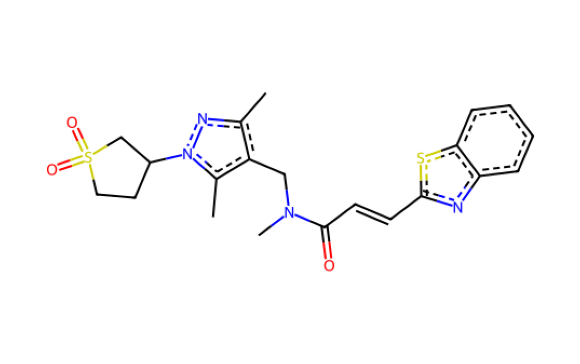

generated molecule instances (3)


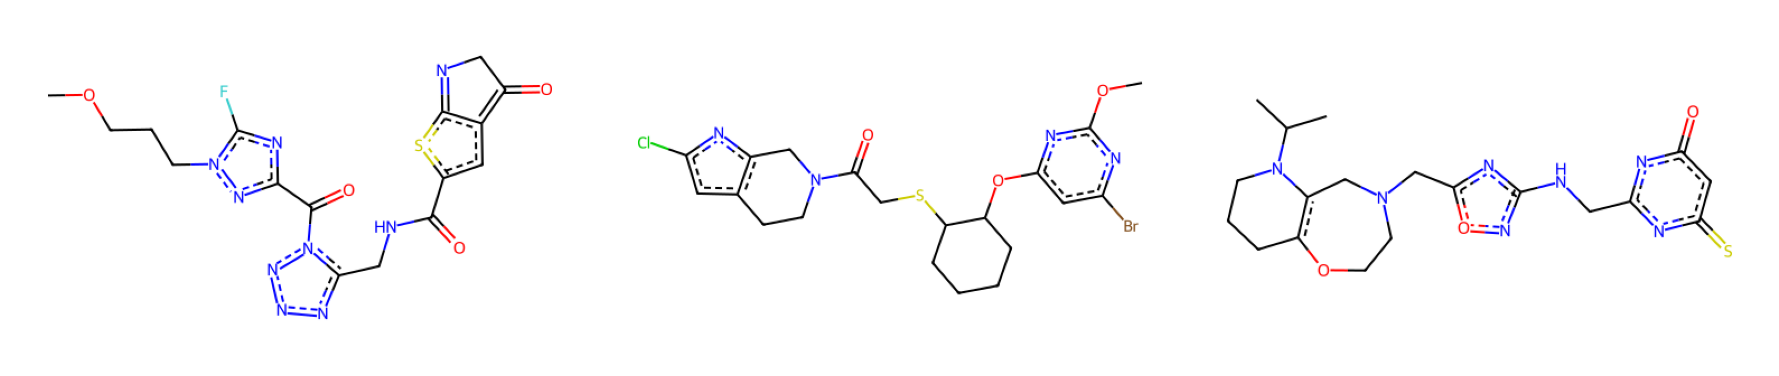

seed molecule


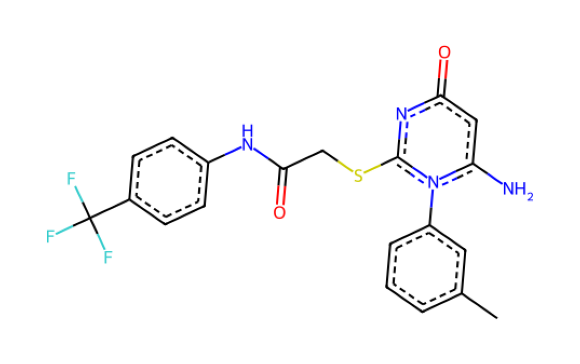

generated molecule instances (3)


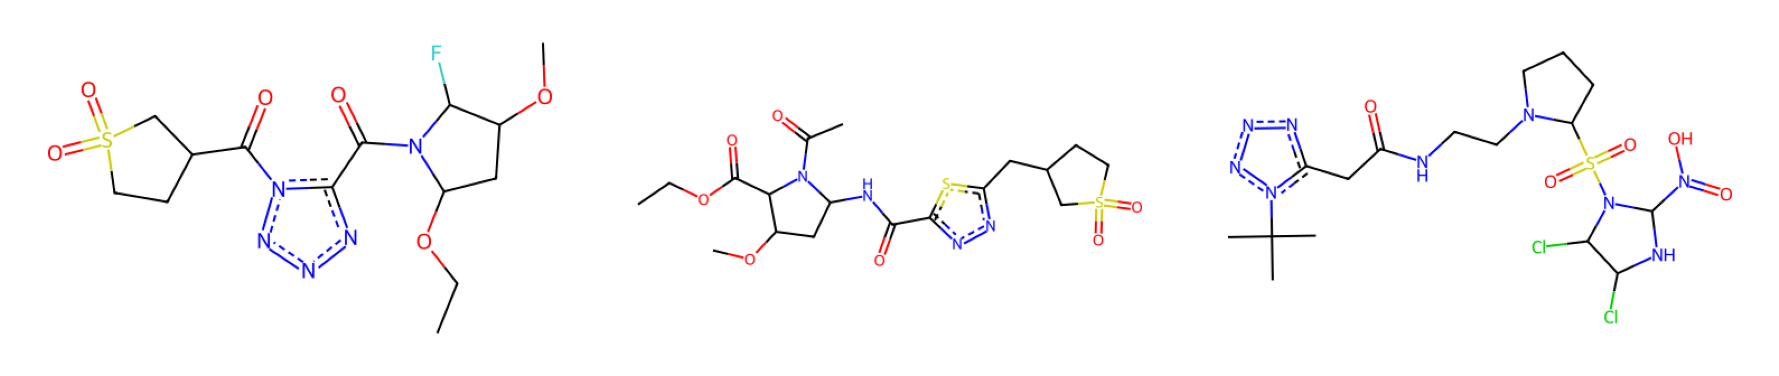

seed molecule


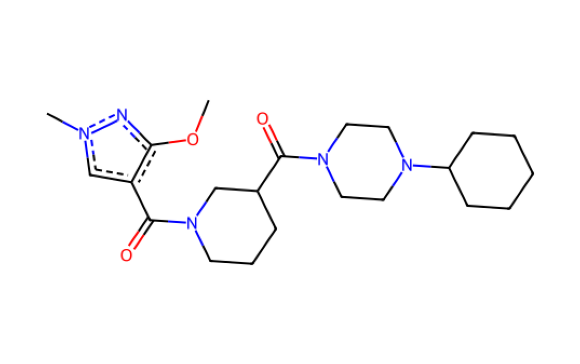

generated molecule instances (2)


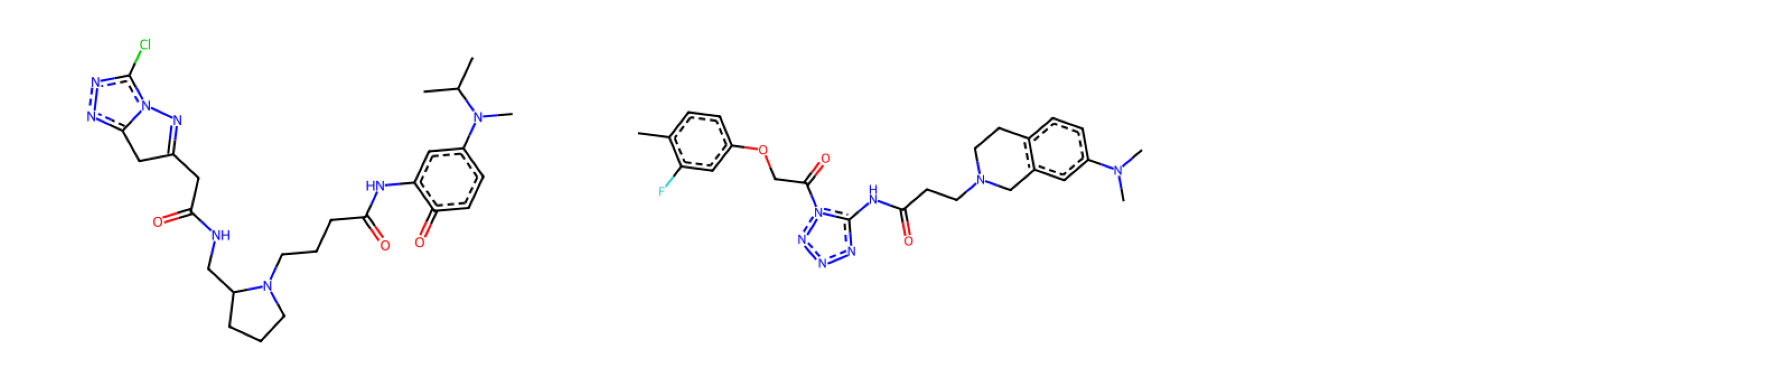

seed molecule


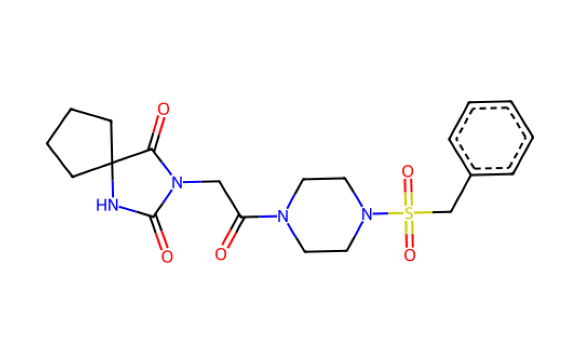

generated molecule instances (3)


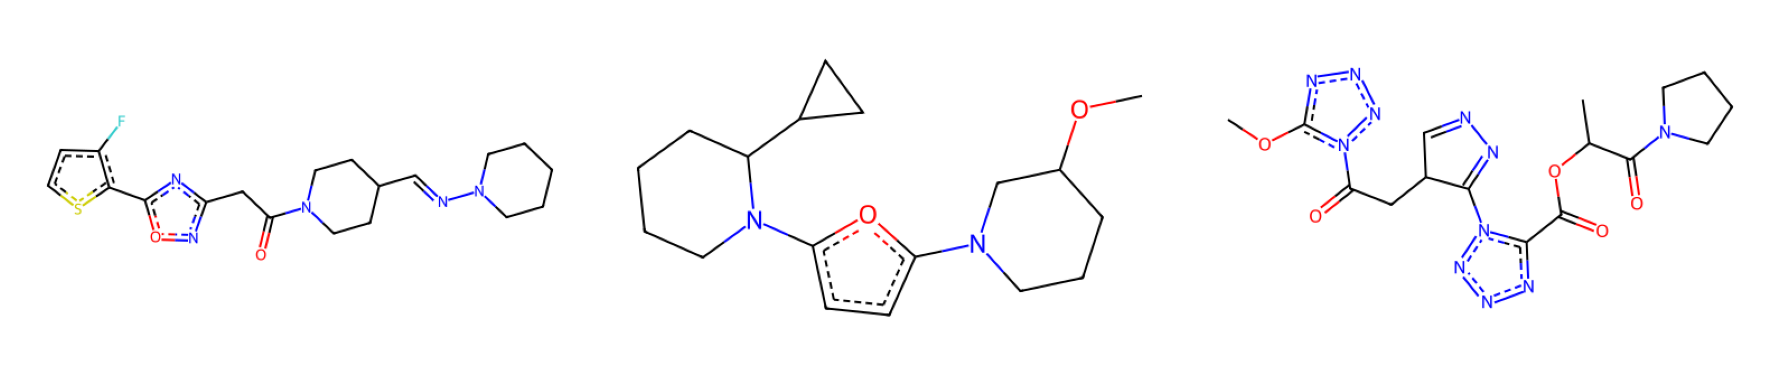

In [23]:
if not generated_graphs:
    print("No generated molecules to display.")
else:
    for sample_idx, (seed_idx,seed_graph,seed_interpretation_graph,generated_interpretation_graph,generated_instances,) in enumerate(zip(generator.last_successful_sampled_indices_,generator.last_seed_graphs_,generator.last_seed_interpretation_graphs_,generator.last_generated_interpretation_graphs_,generated_groups,)):
        print("seed molecule")
        display_graphs([seed_graph], n_graphs_per_line=1)
        
        print(f"generated molecule instances ({len(generated_instances)})")
        display_graphs(generated_instances, n_graphs_per_line=n_instances_per_sample)

sample 0 | seed index 2638
seed molecule


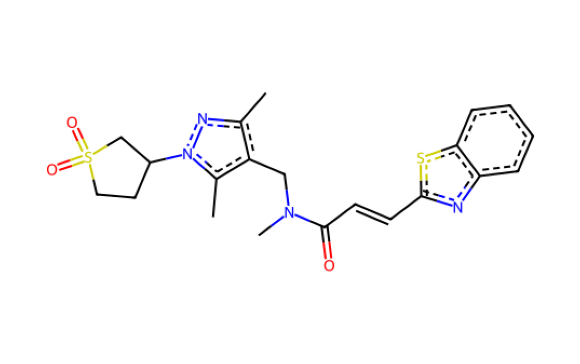

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


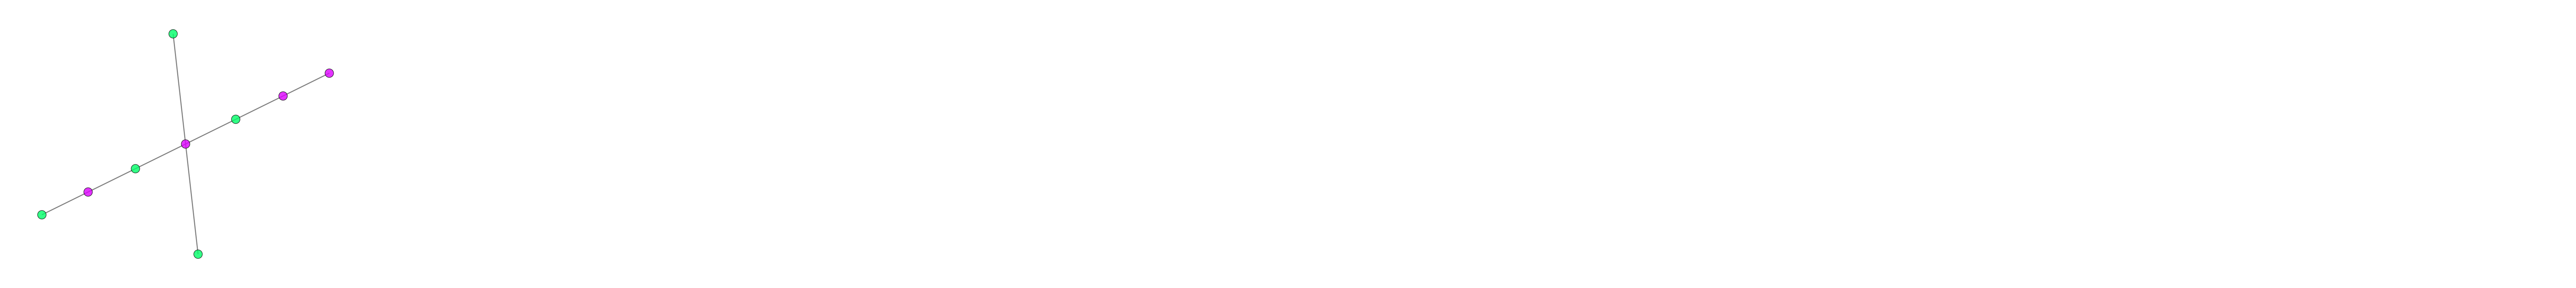

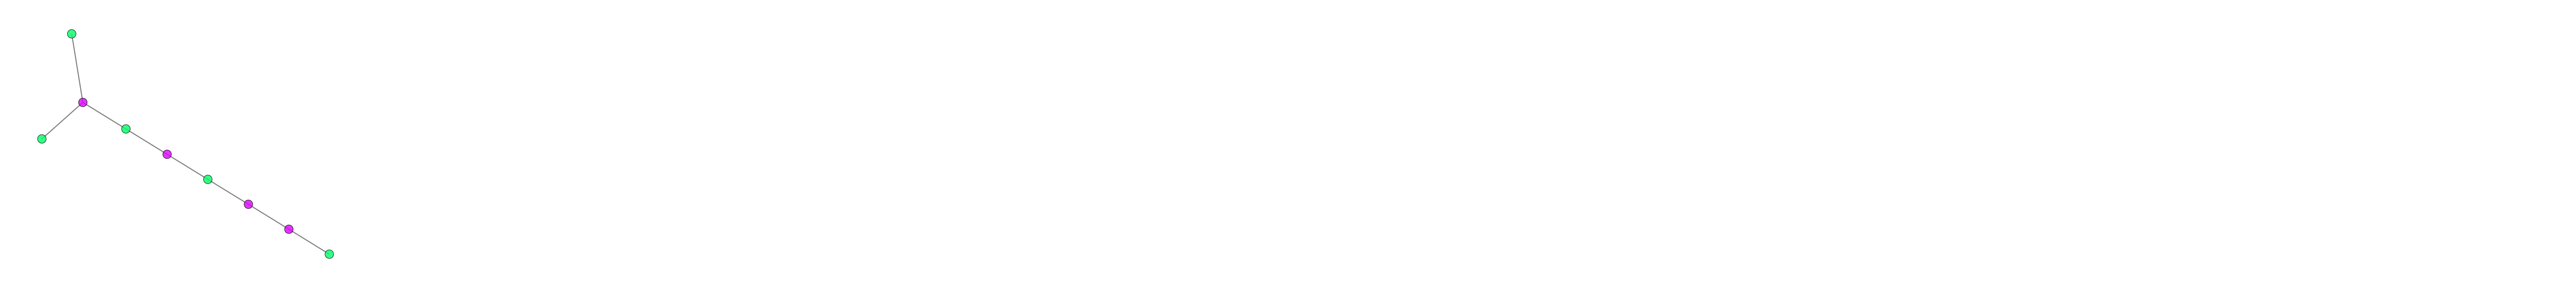

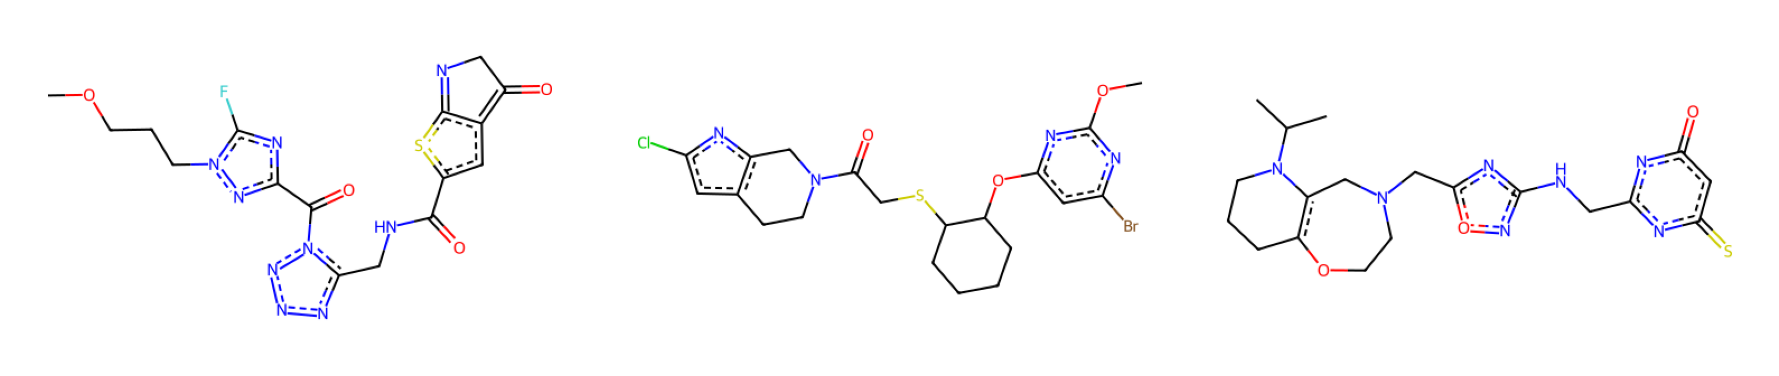

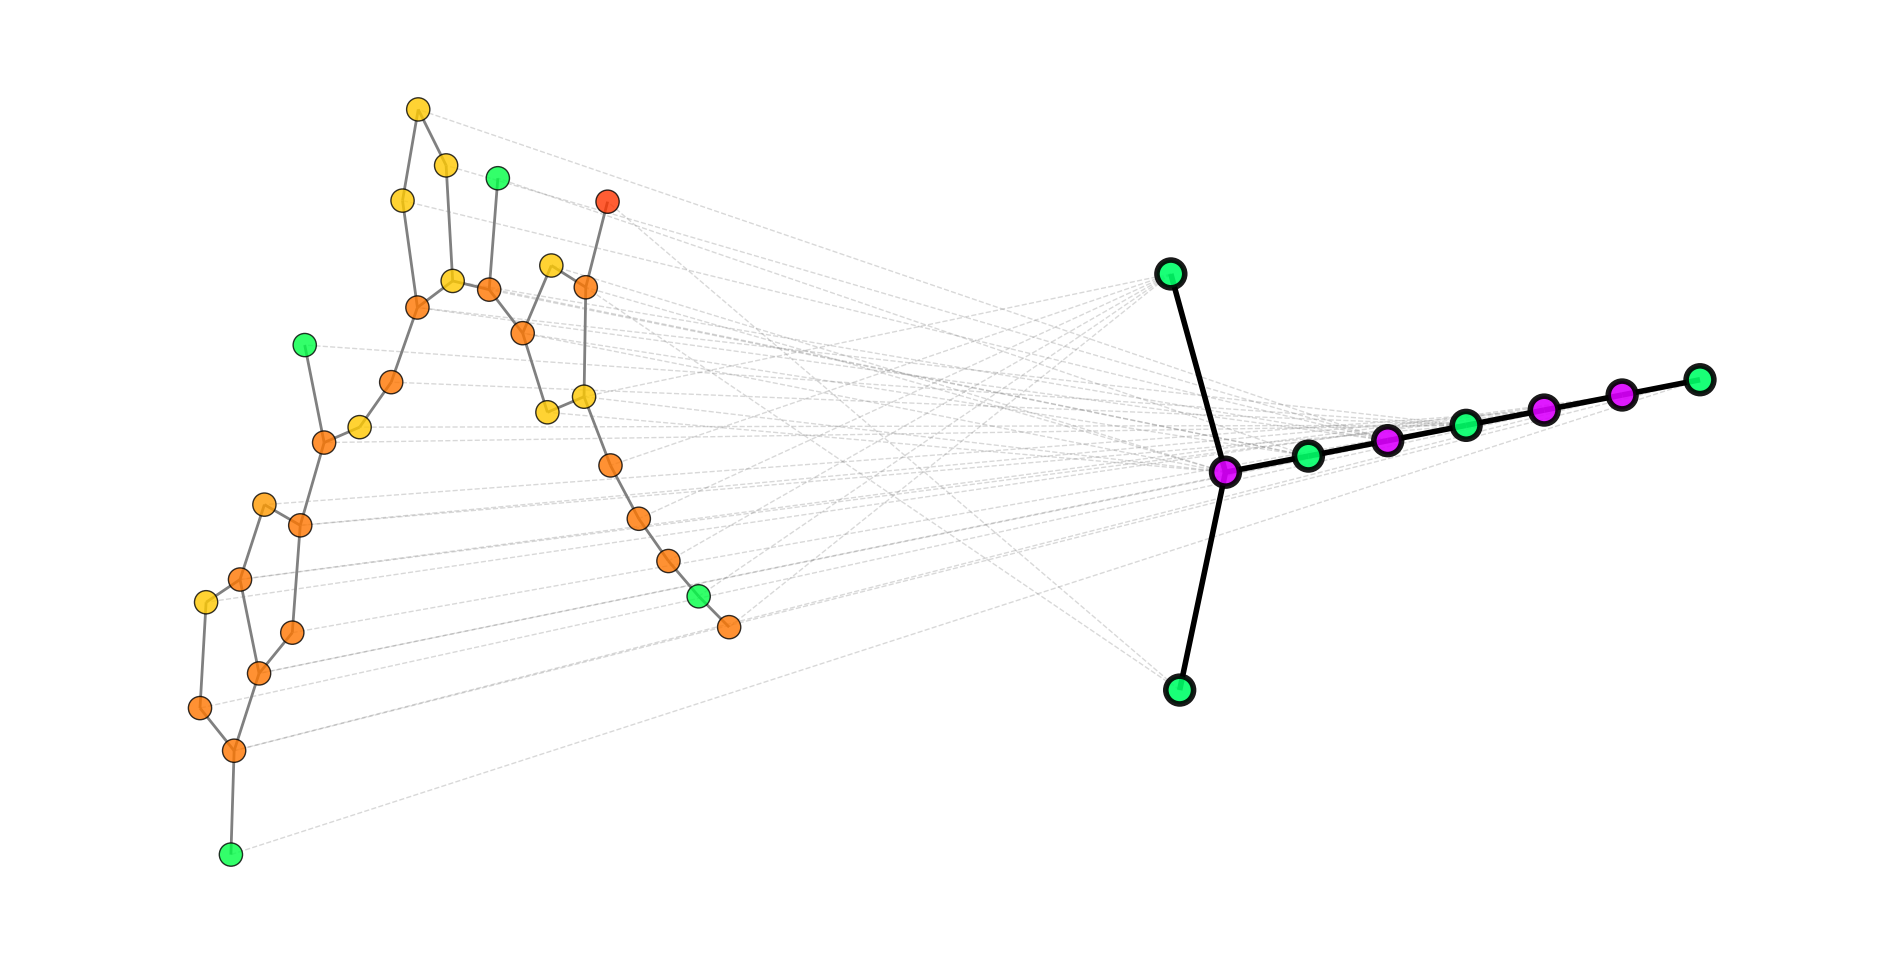

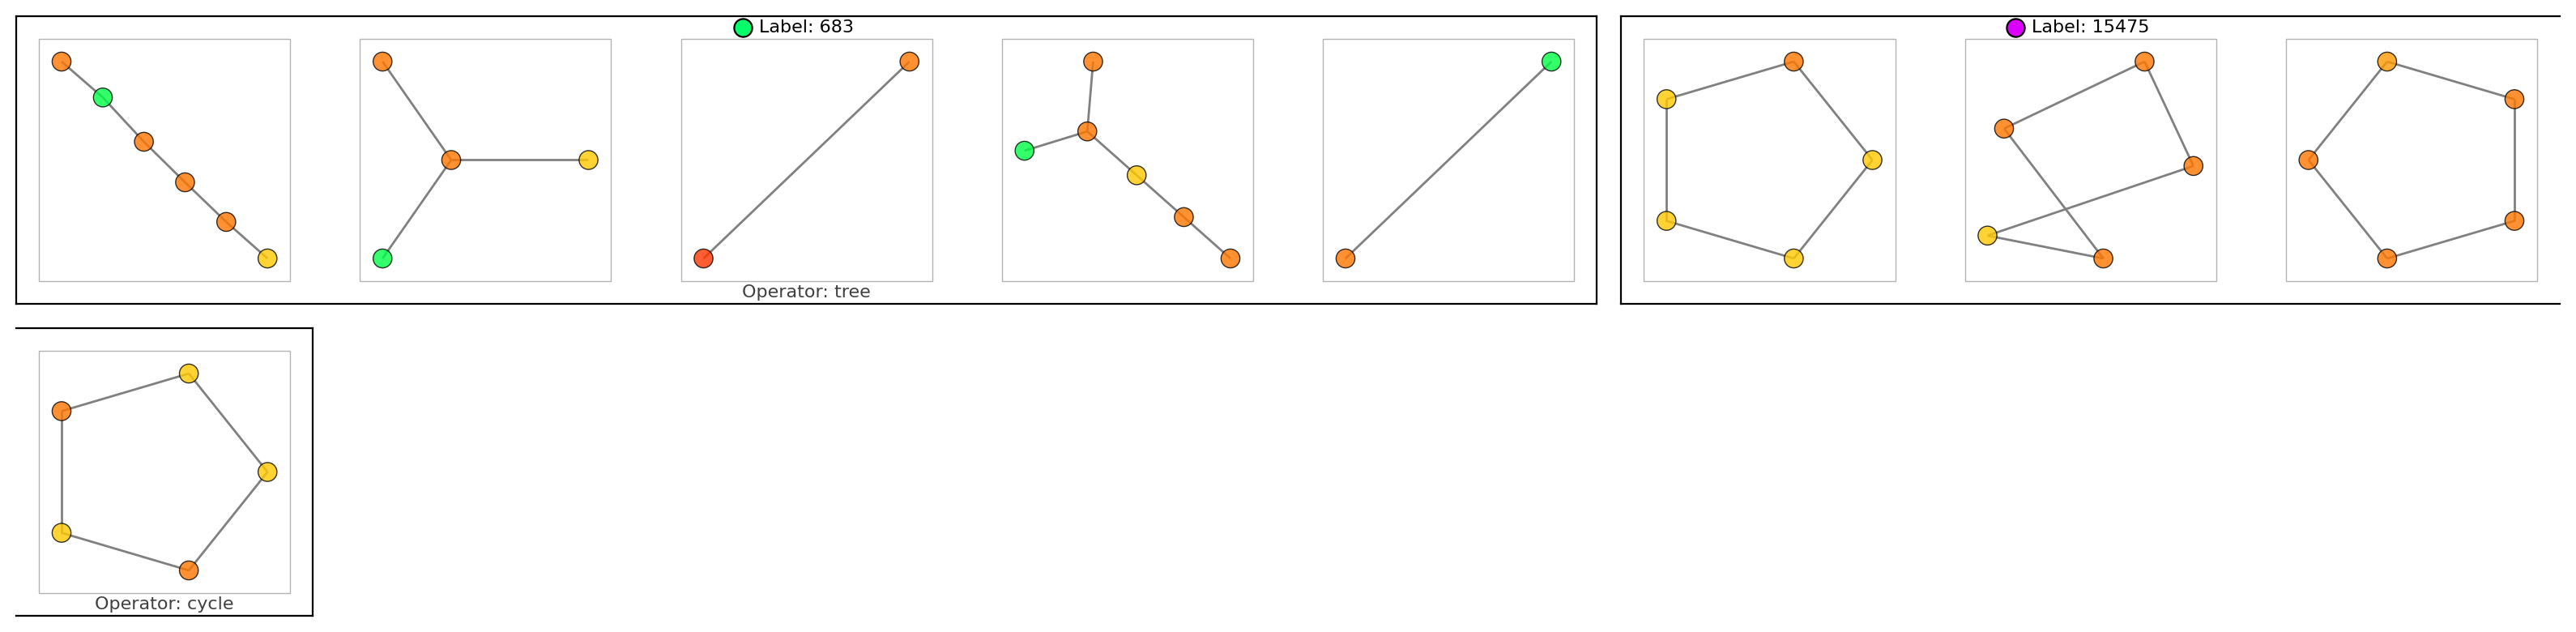

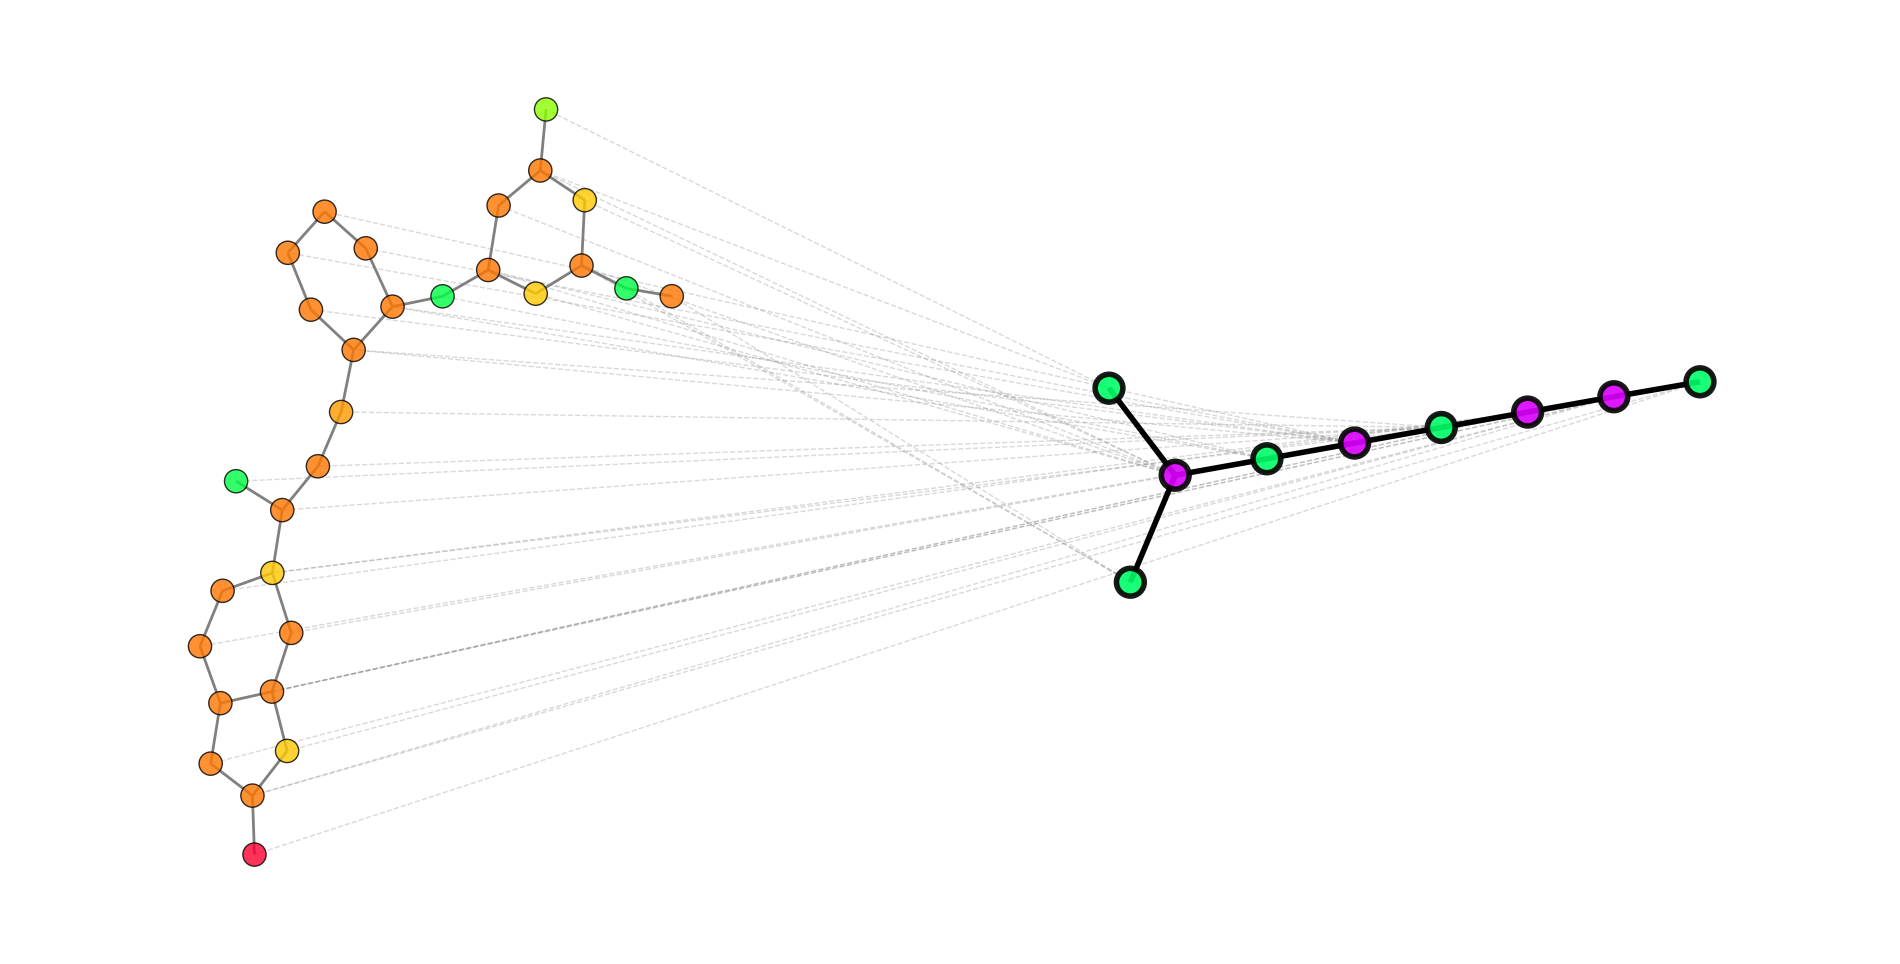

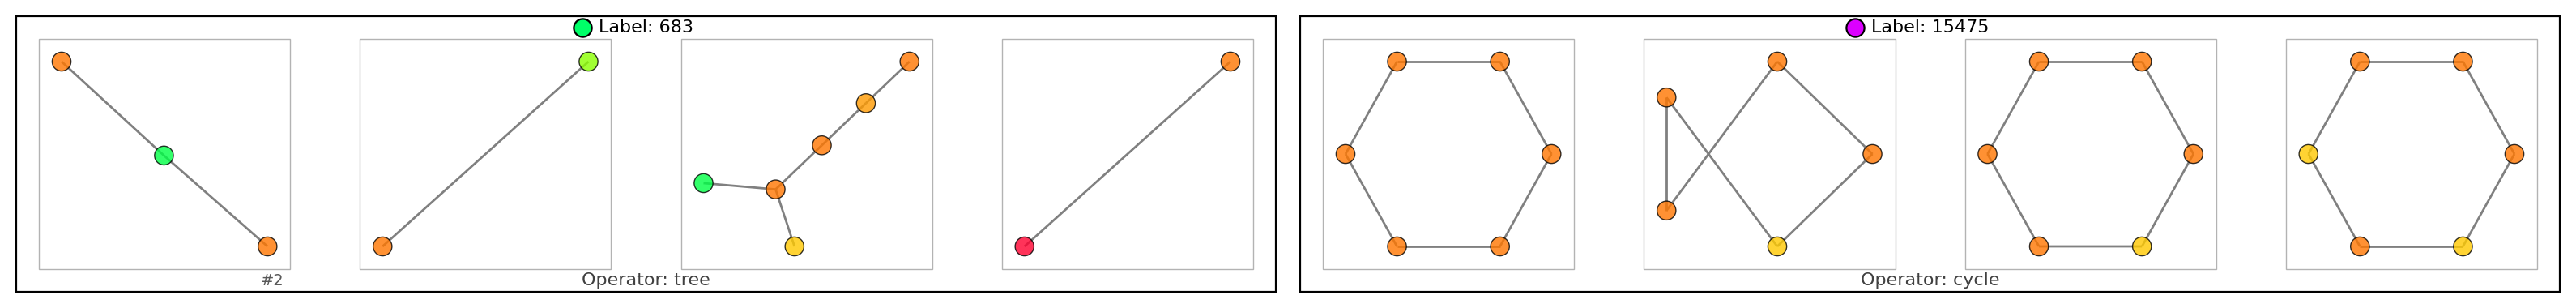

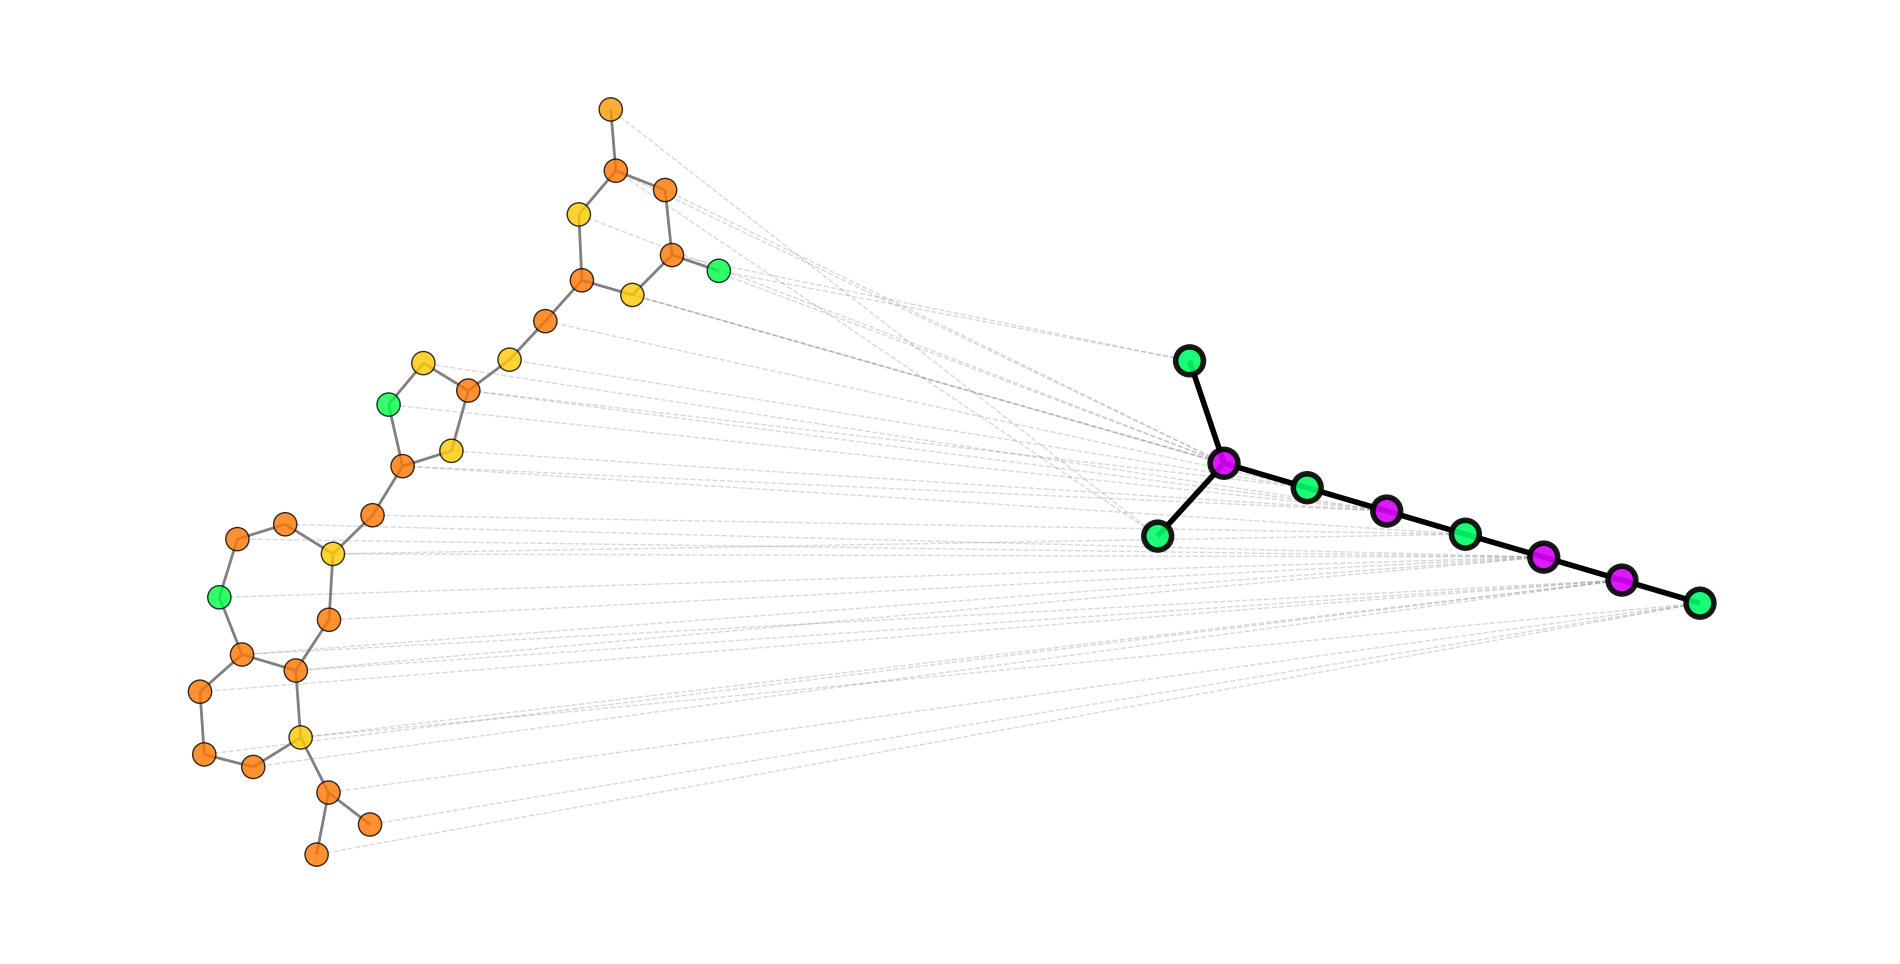

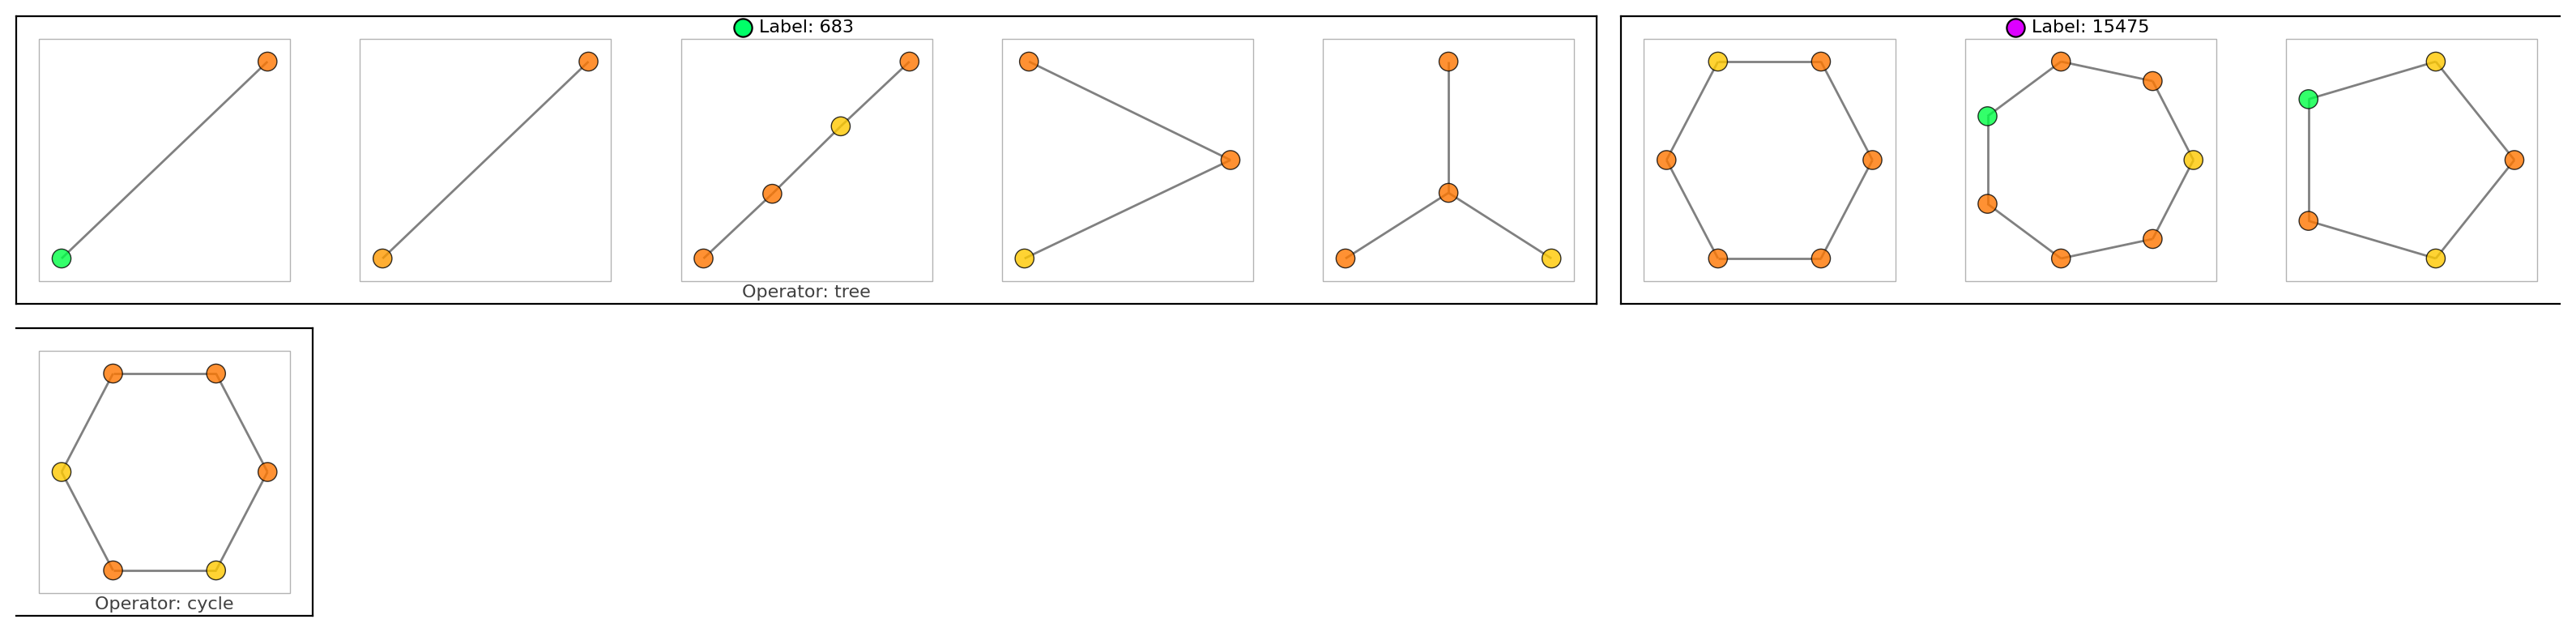

sample 1 | seed index 2683
seed molecule


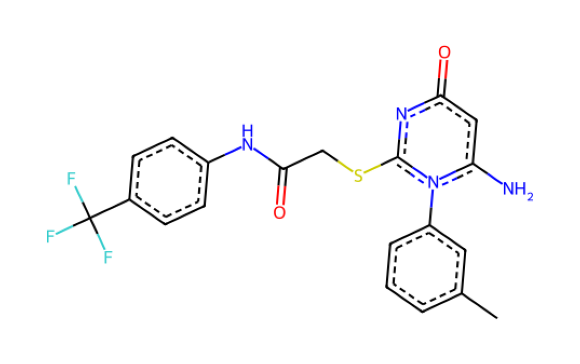

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


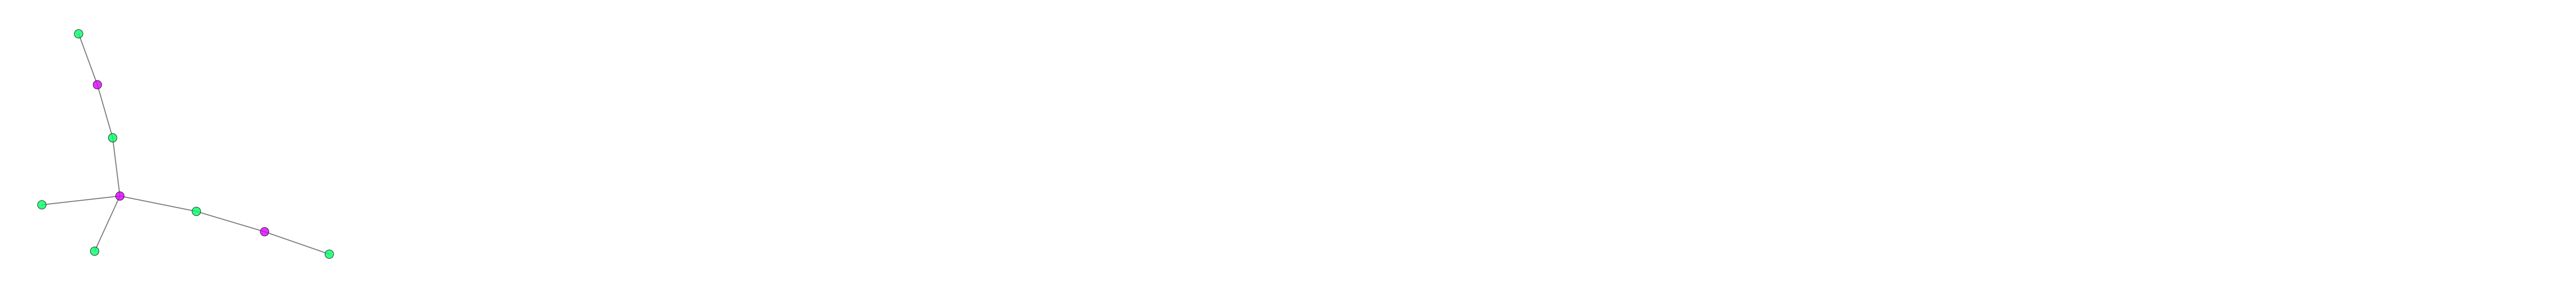

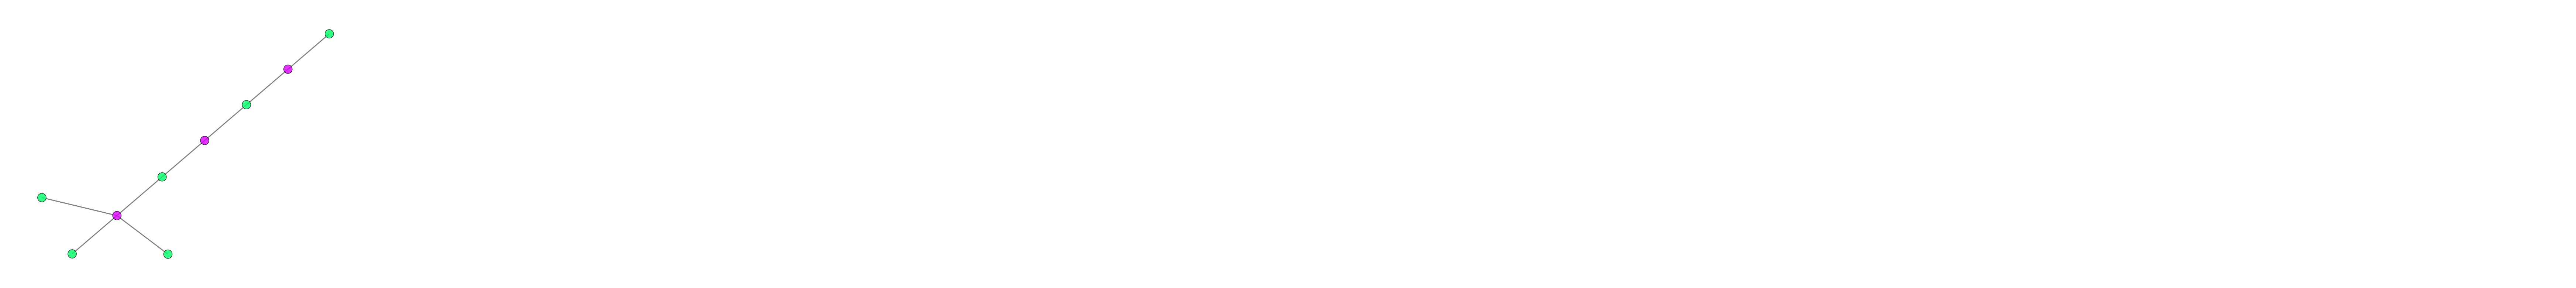

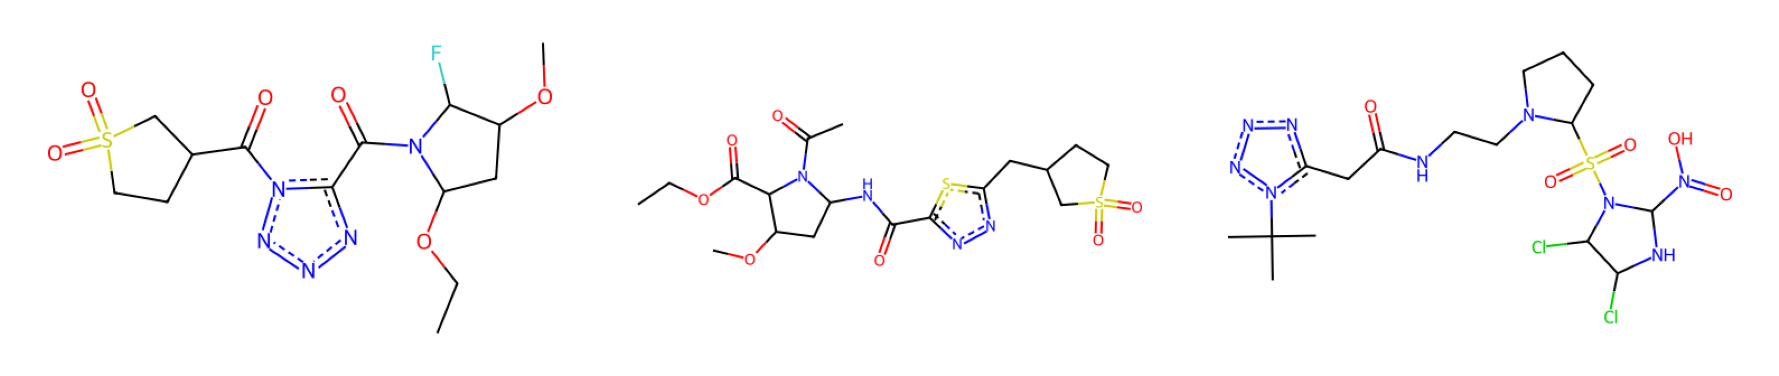

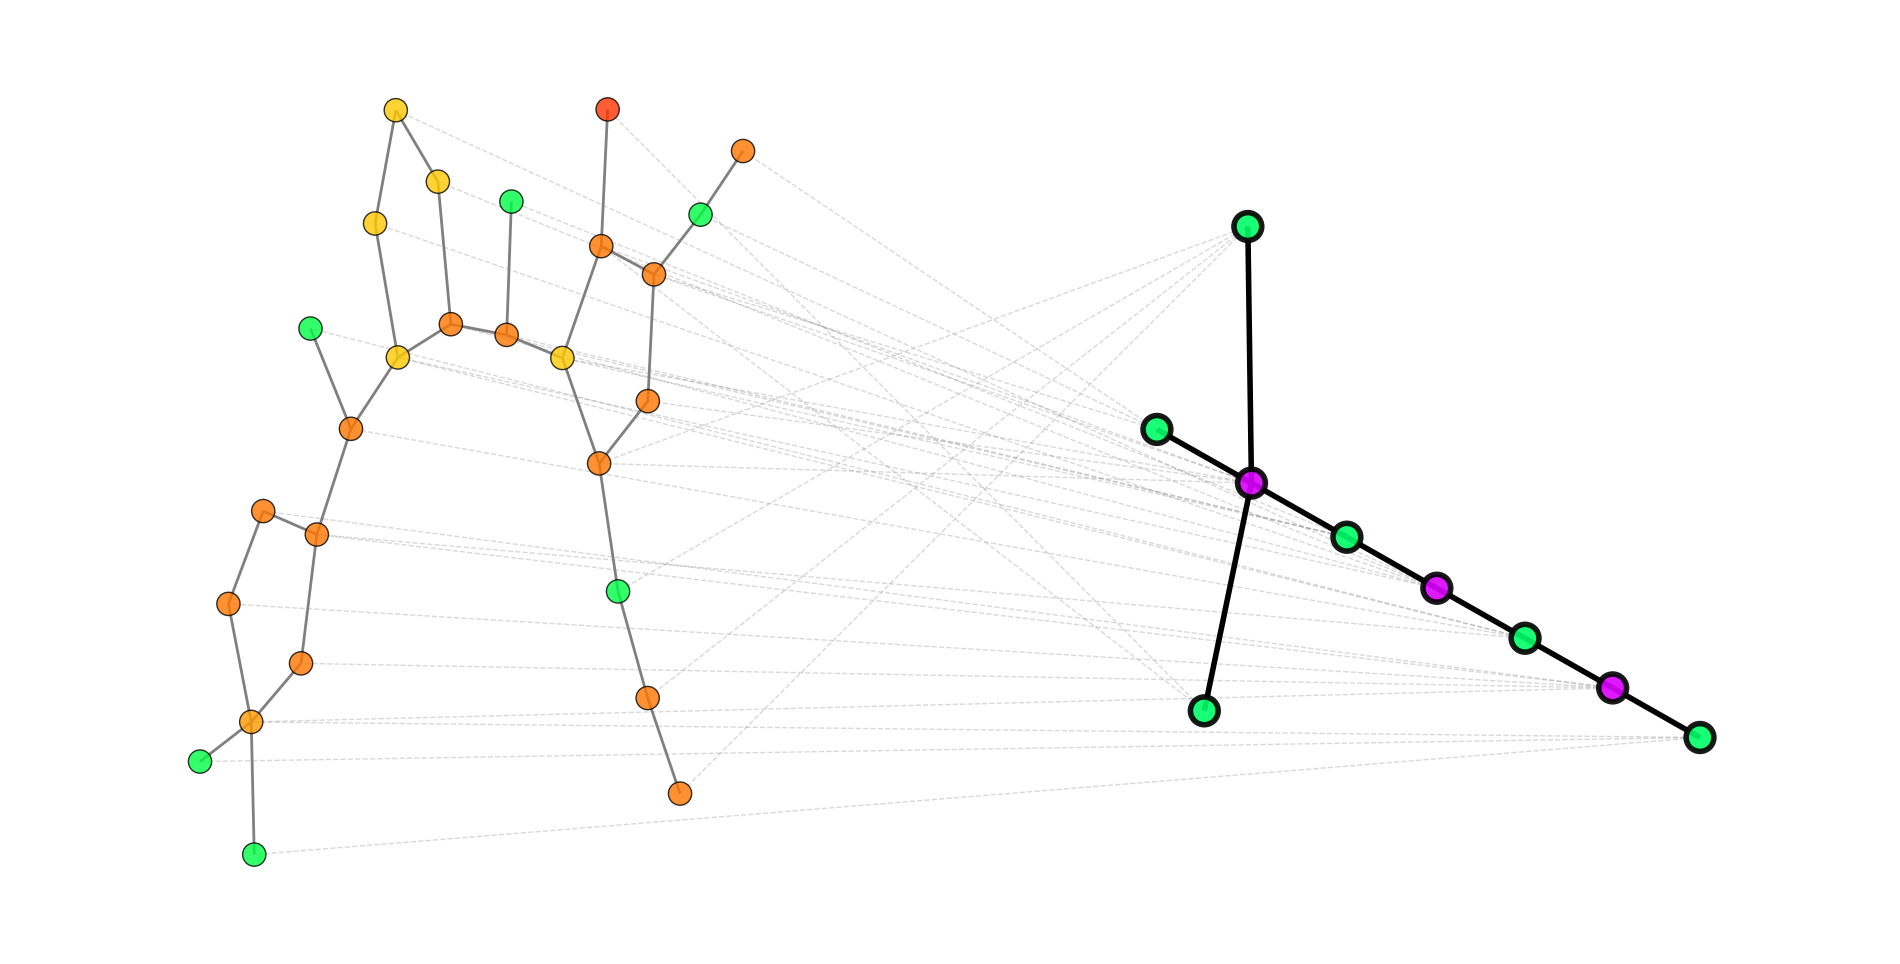

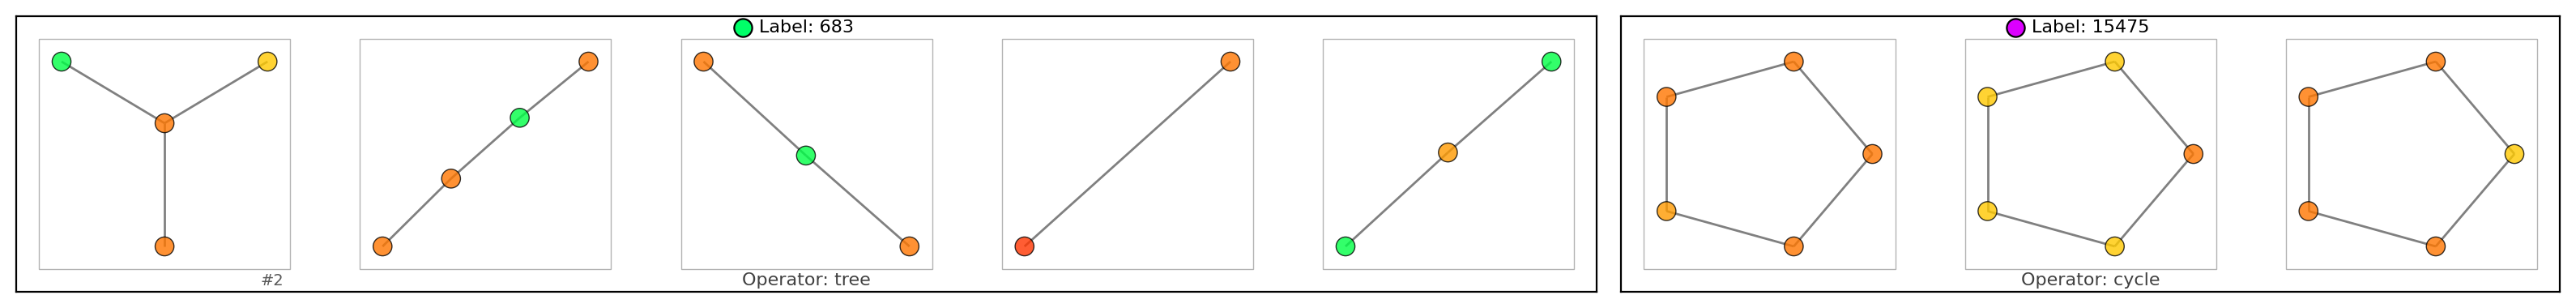

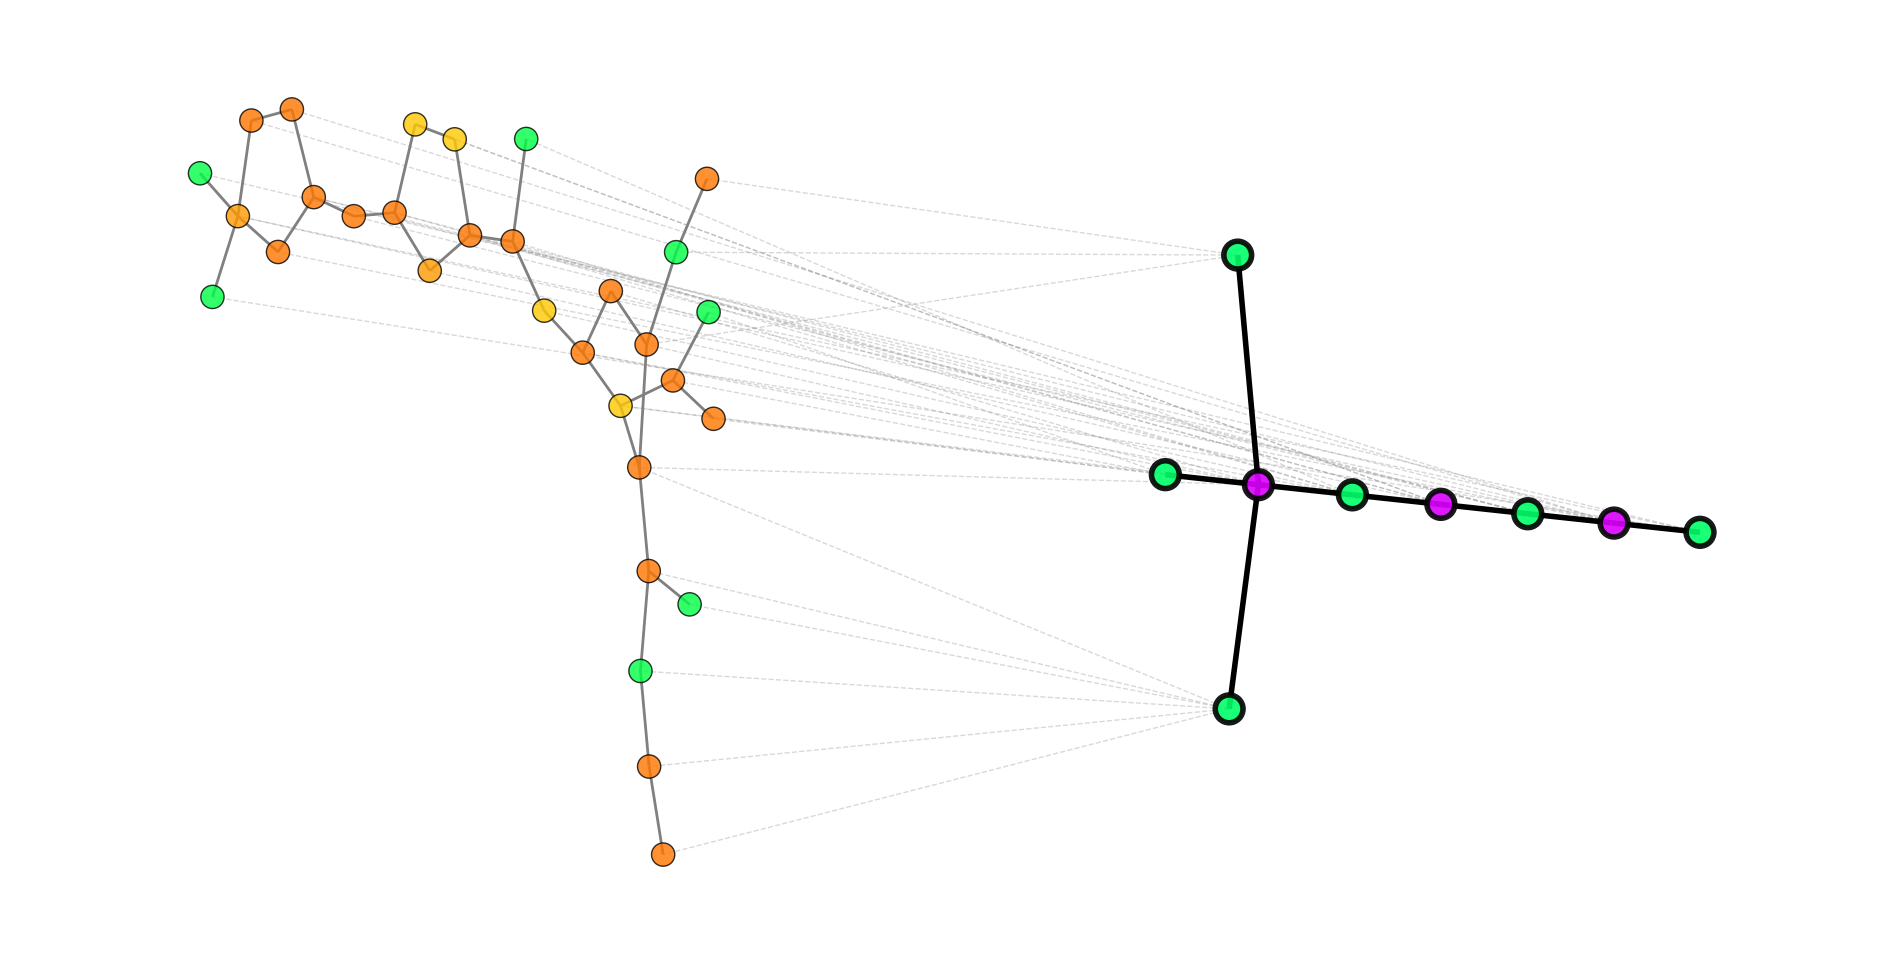

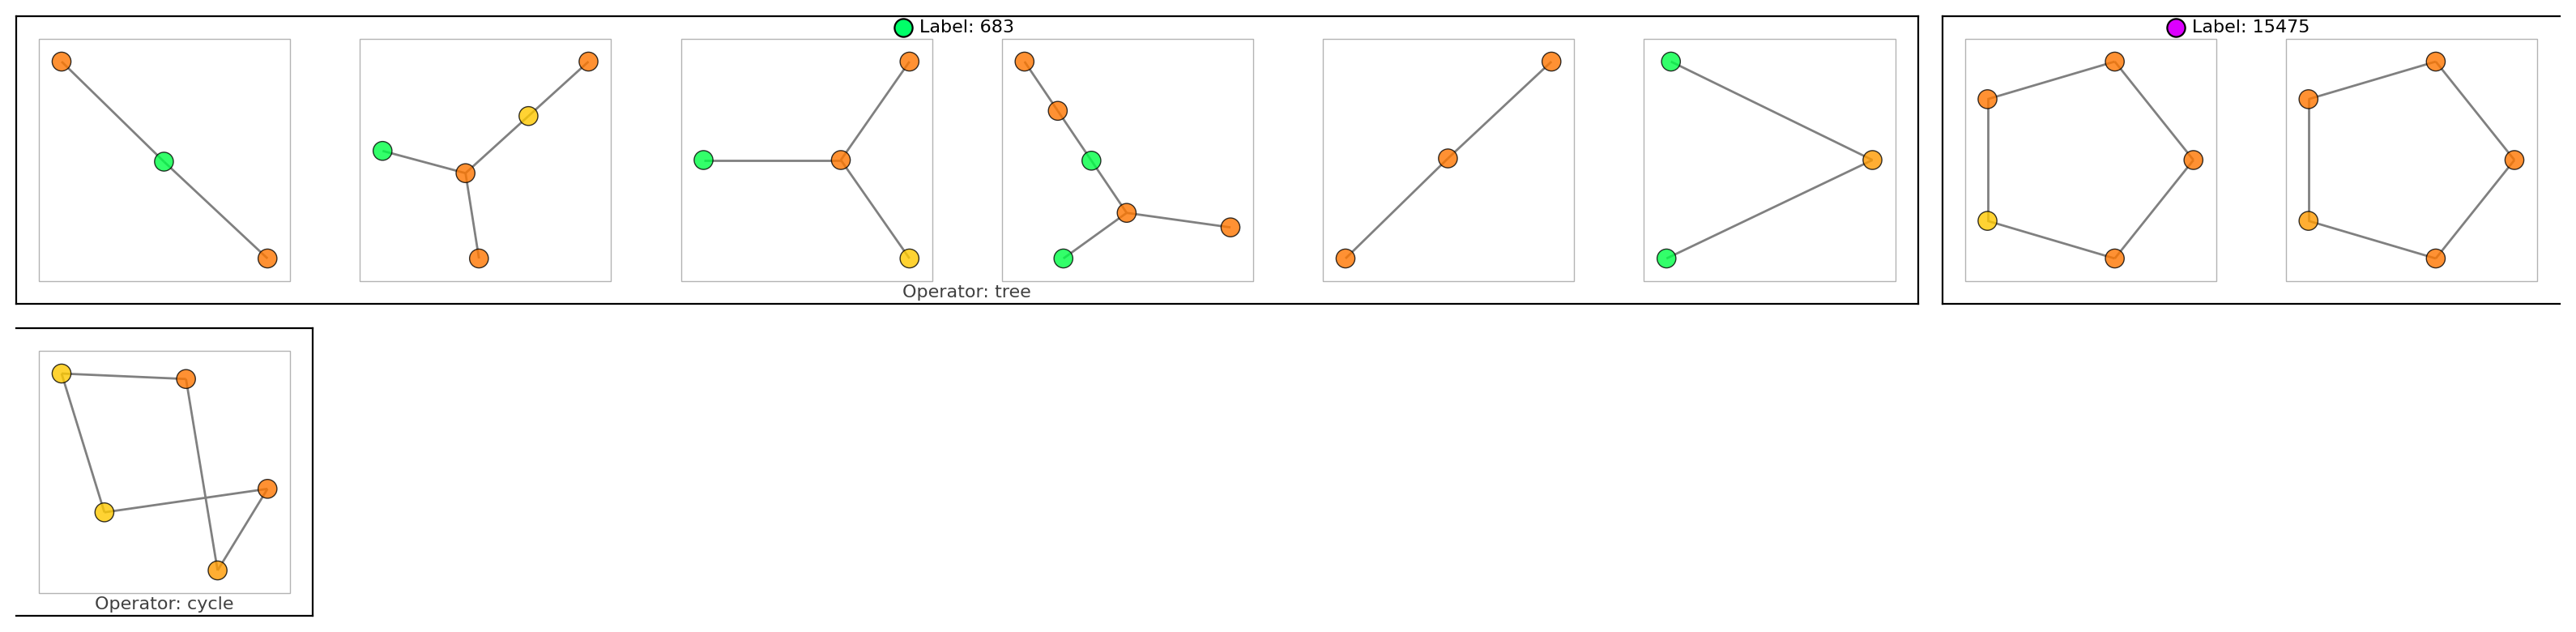

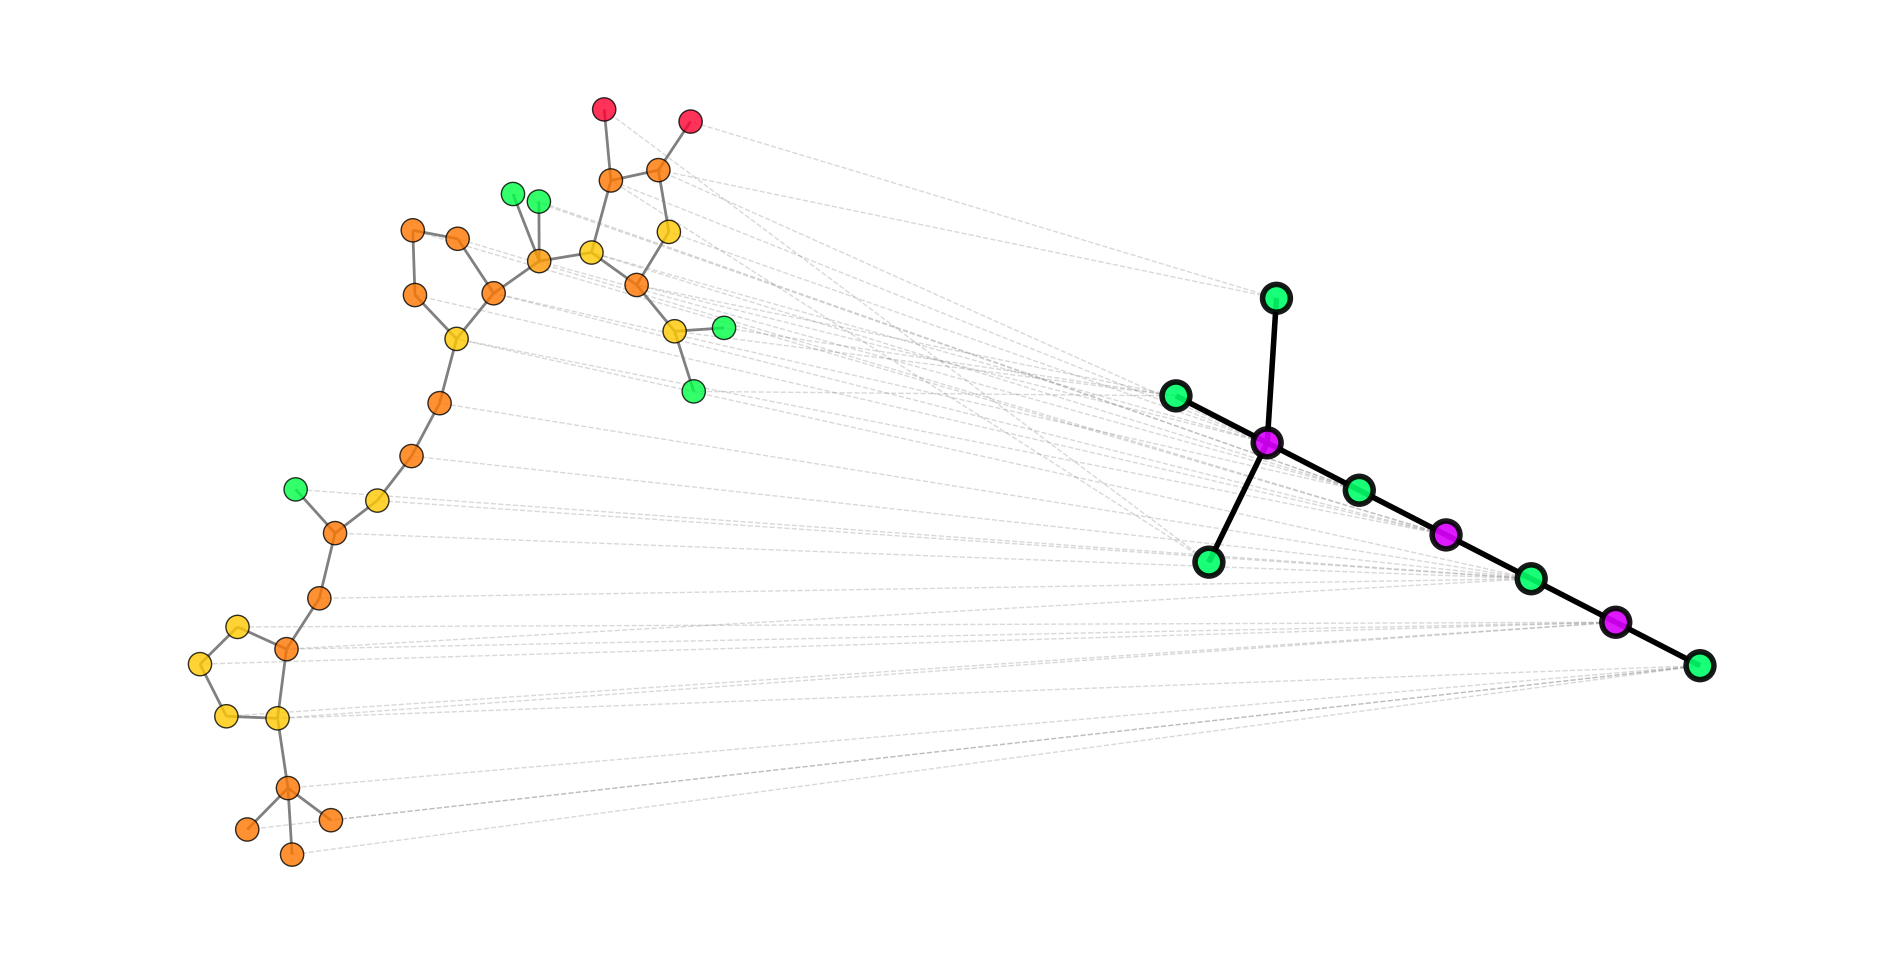

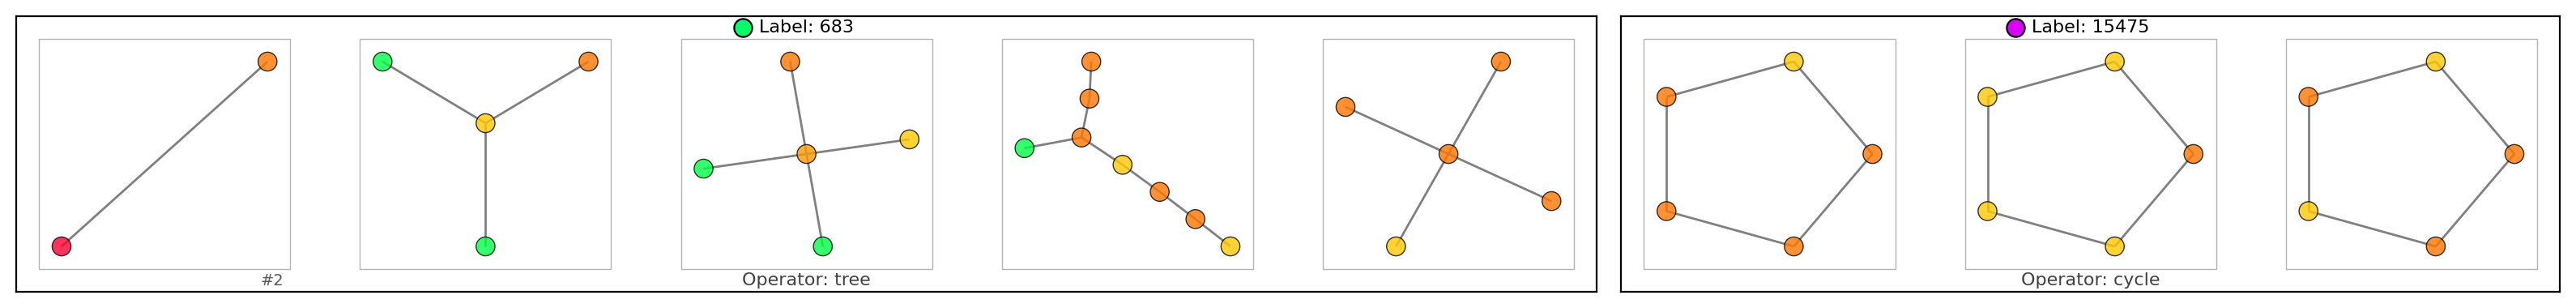

sample 2 | seed index 1135
seed molecule


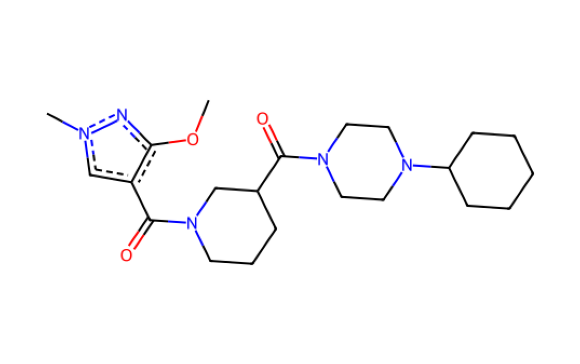

seed interpretation graph
generated interpretation graph
generated molecule instances (2)


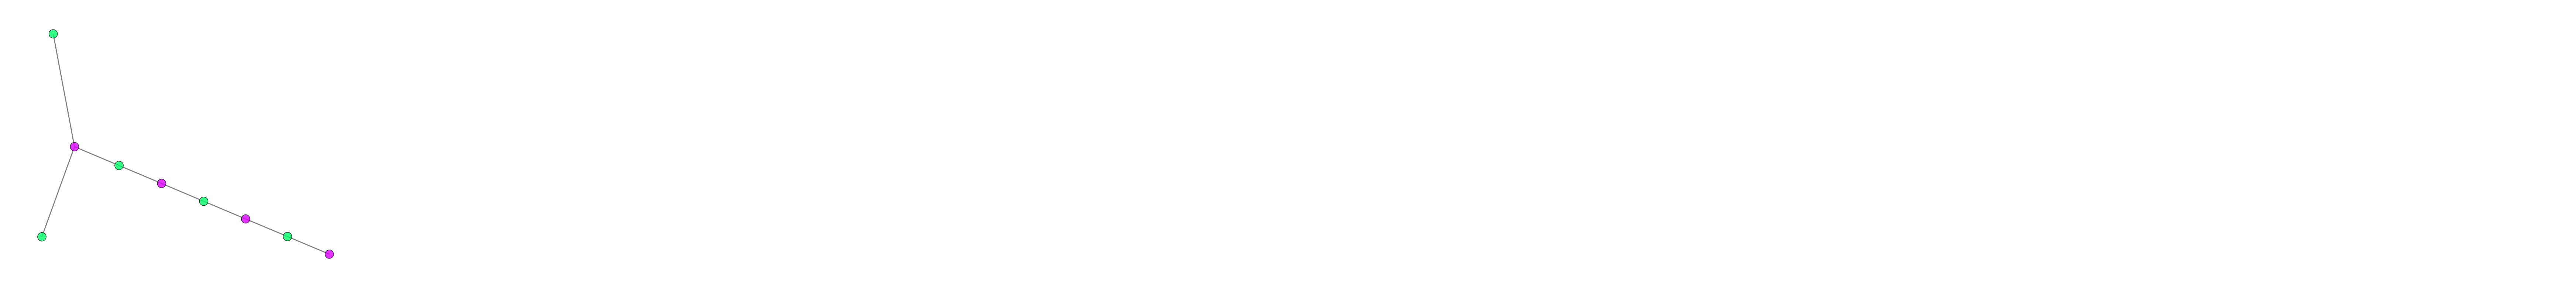

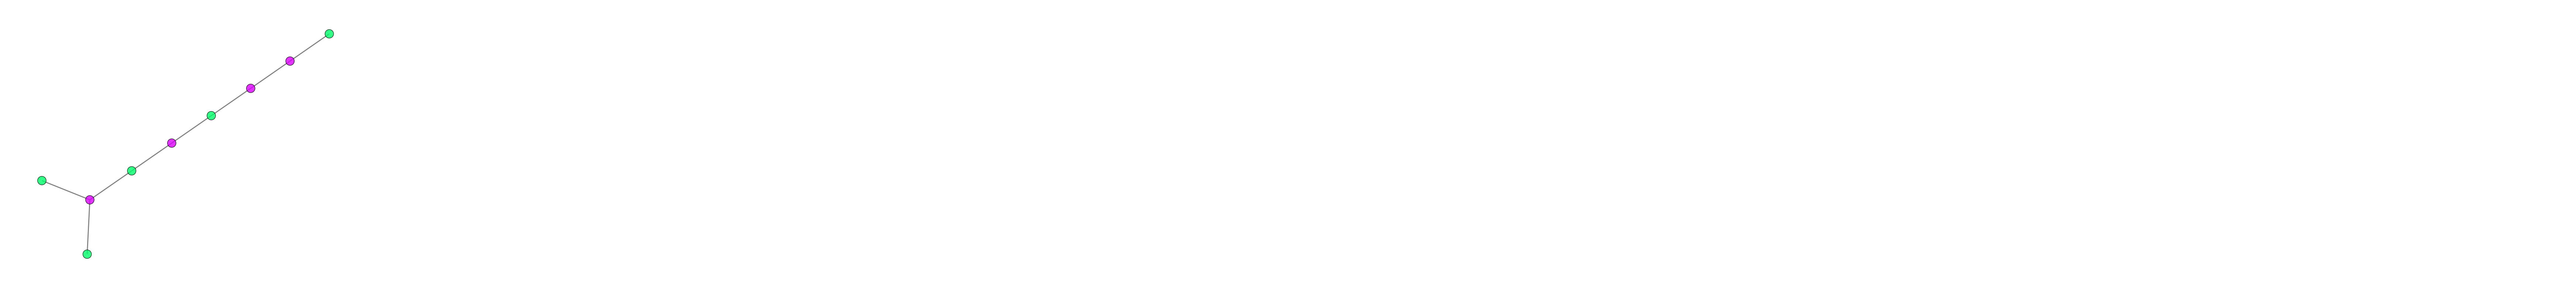

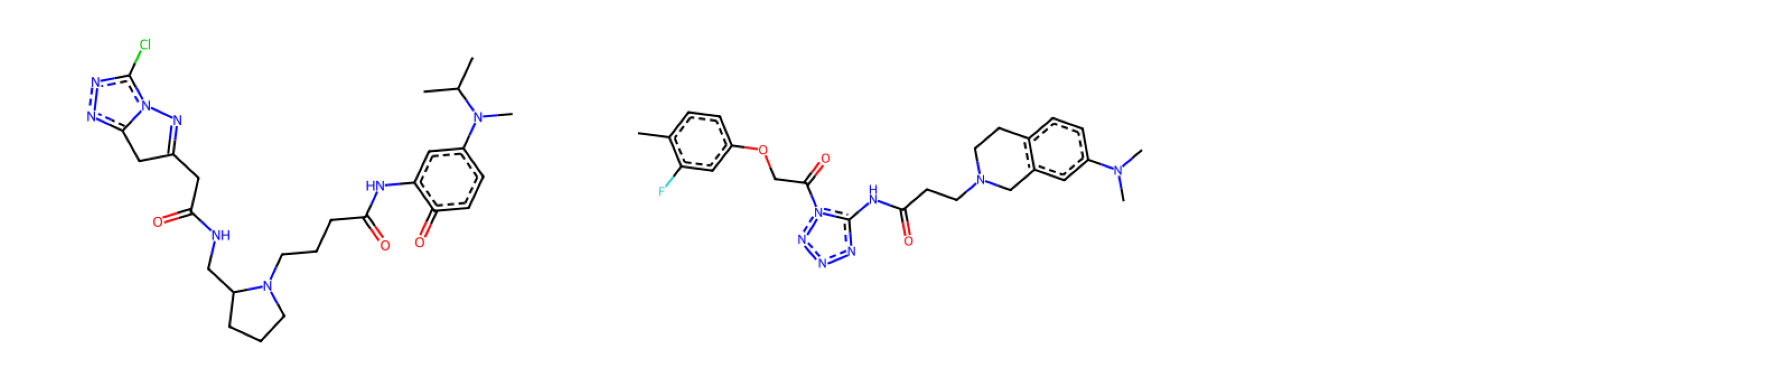

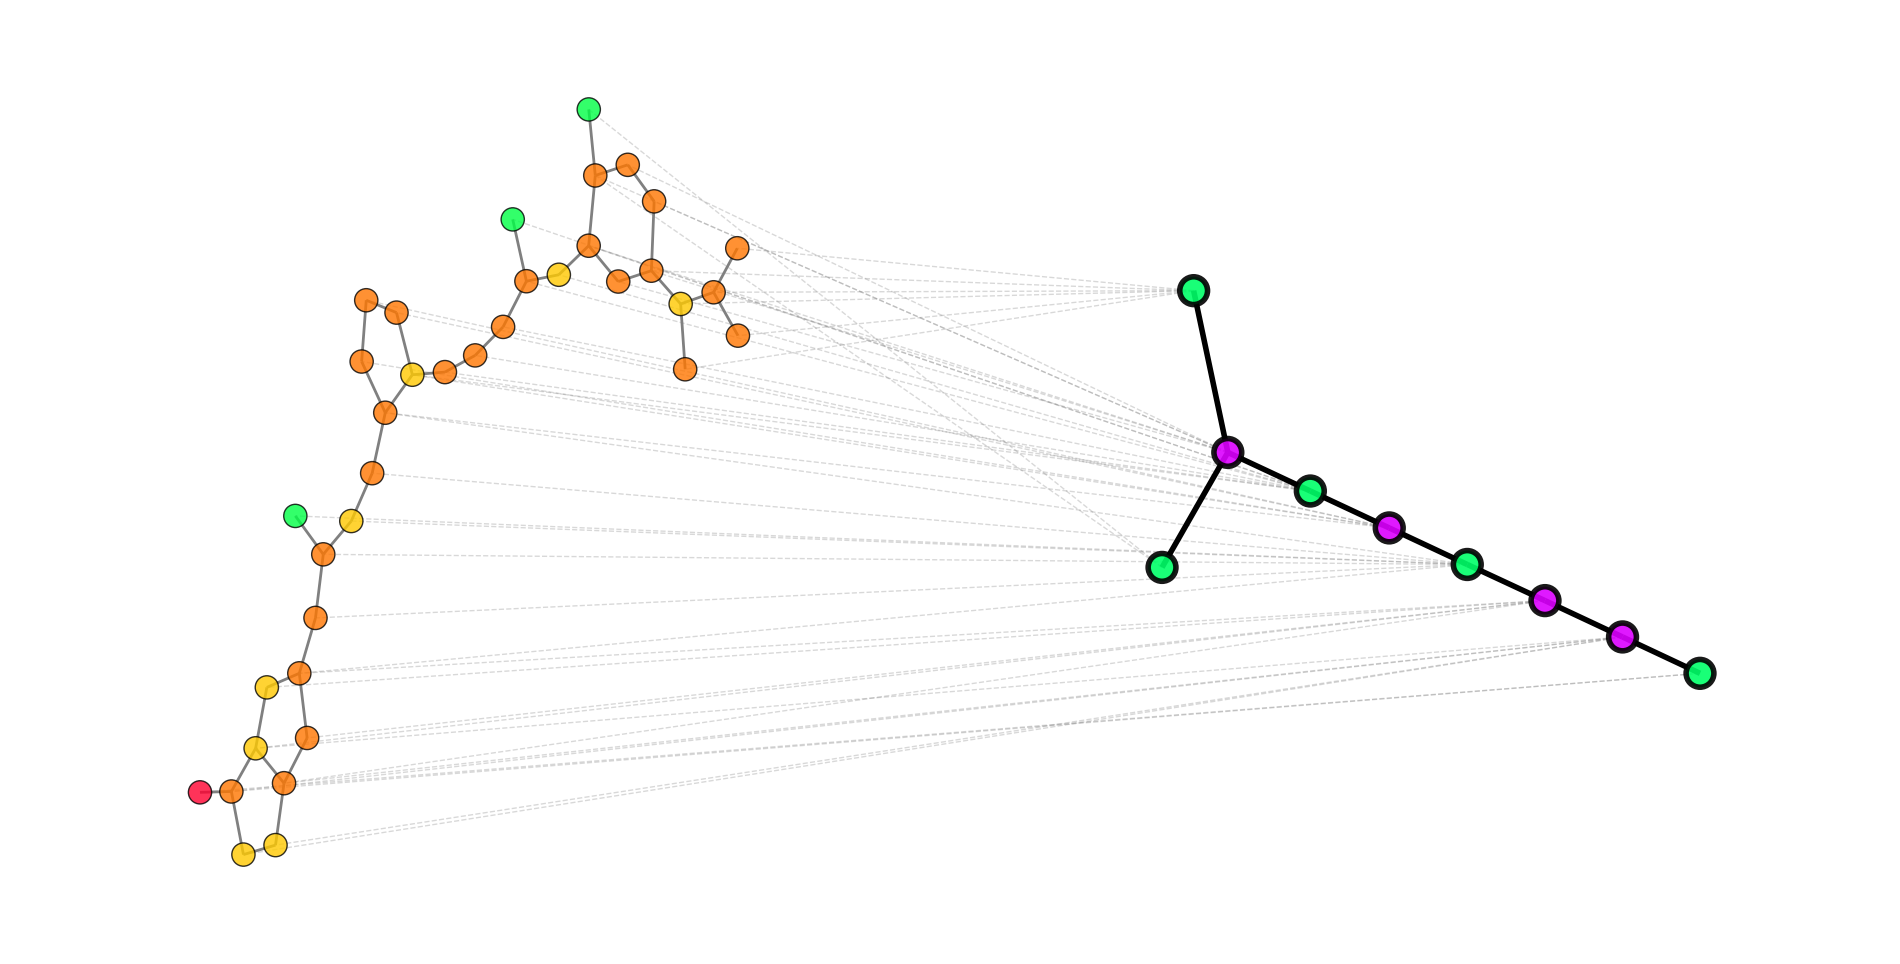

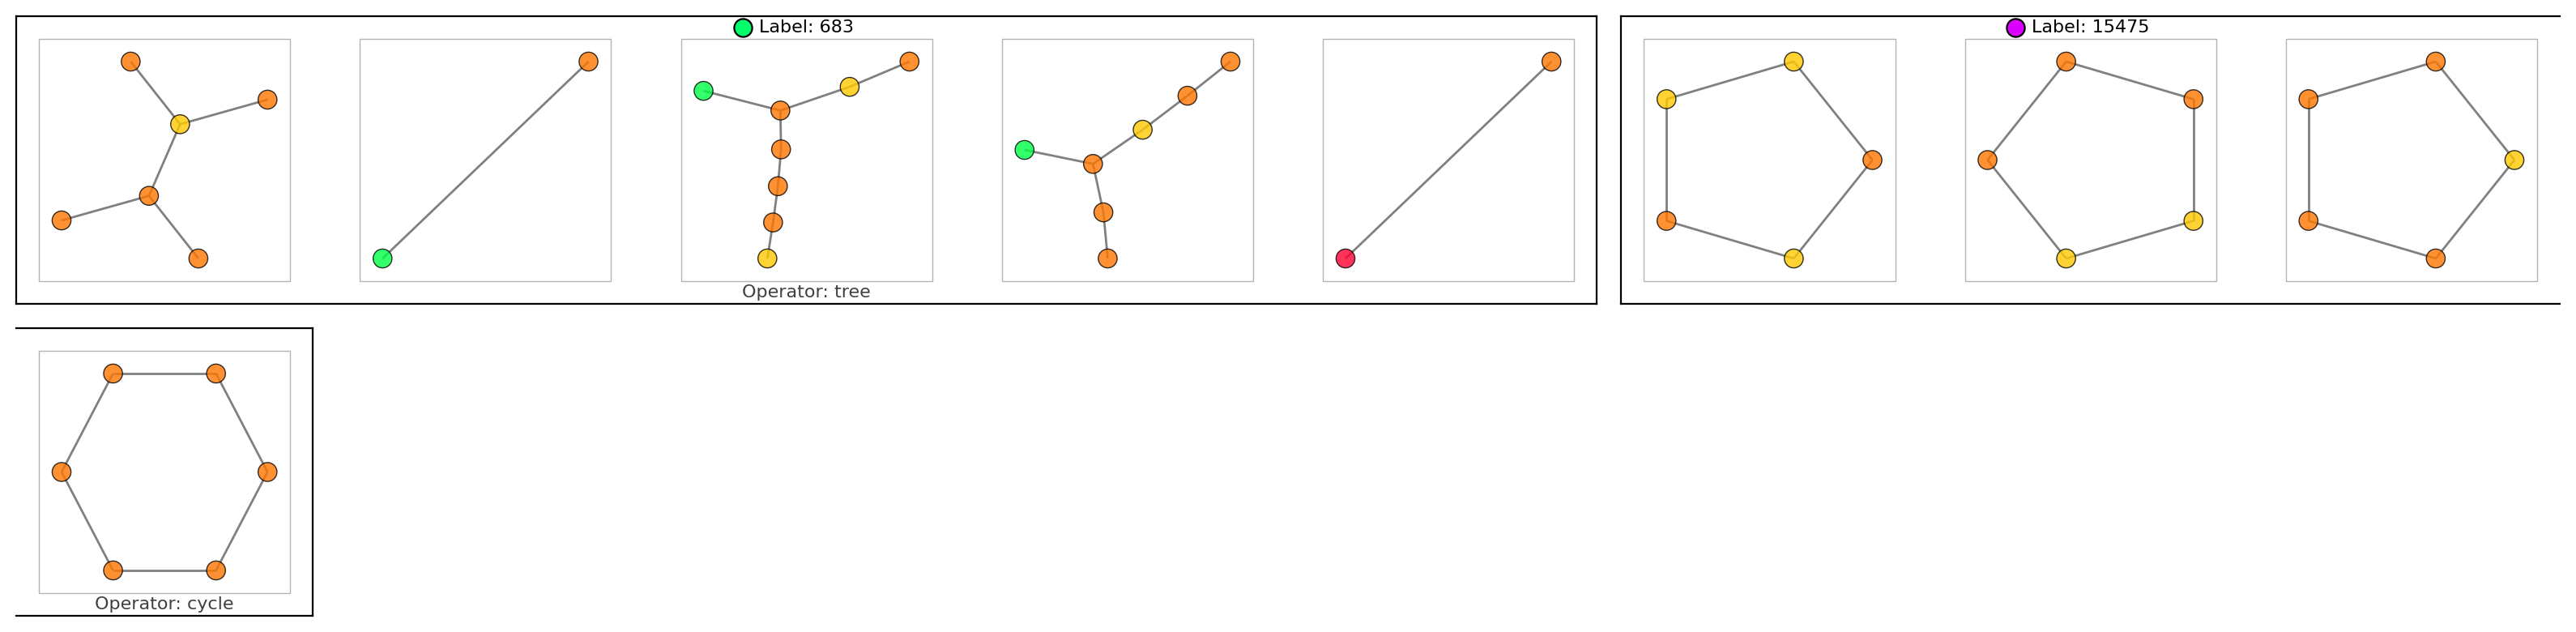

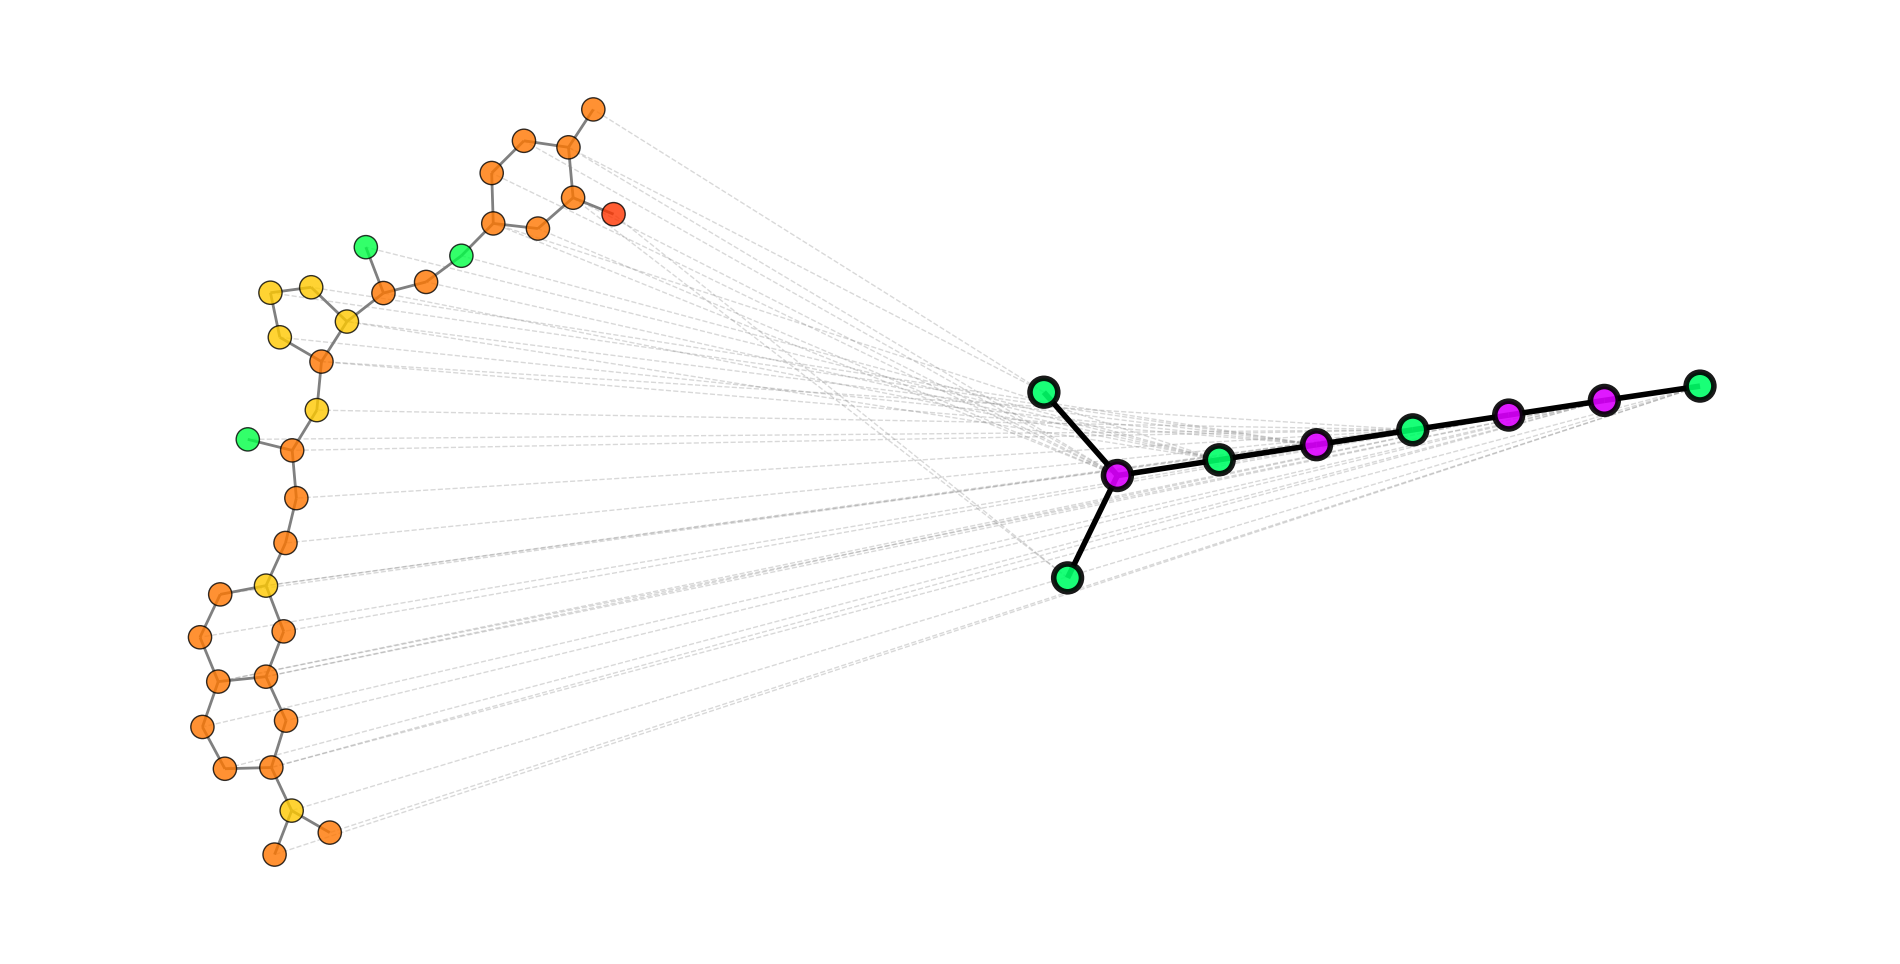

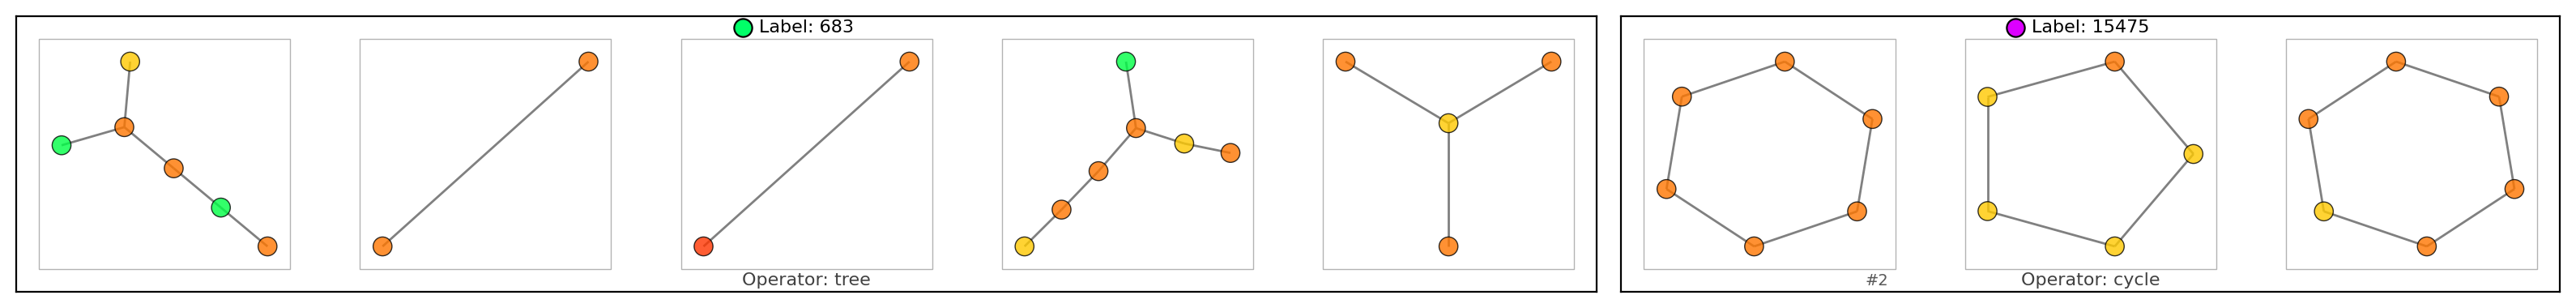

sample 3 | seed index 2591
seed molecule


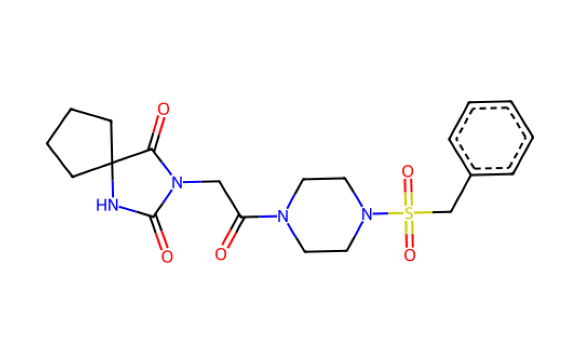

seed interpretation graph
generated interpretation graph
generated molecule instances (3)


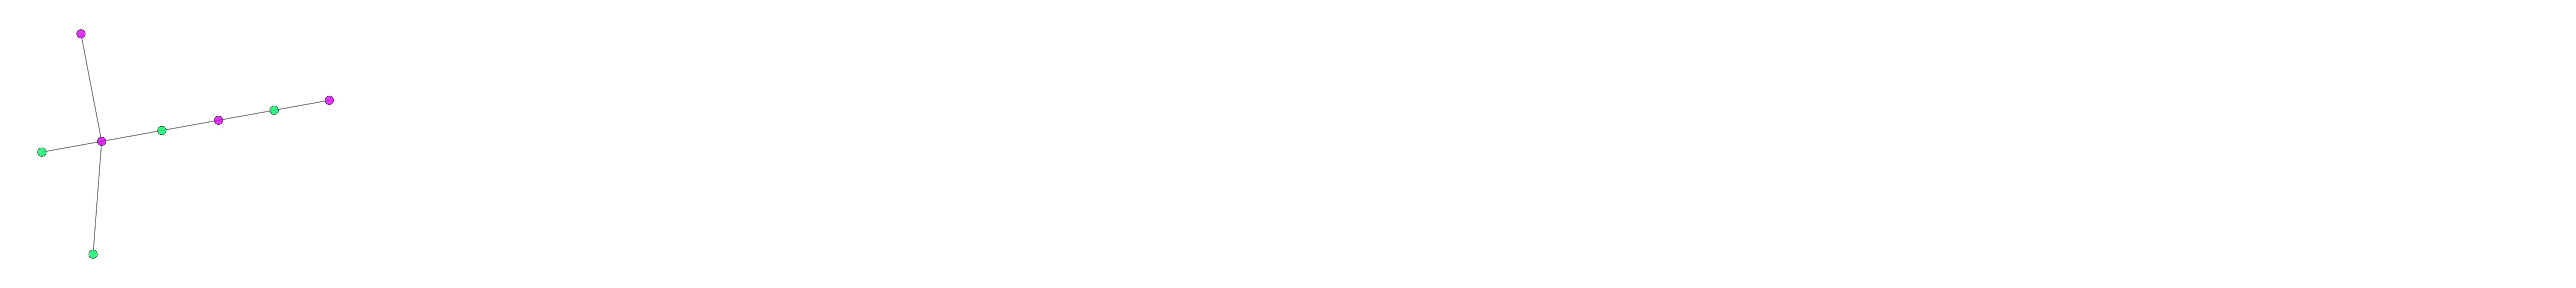

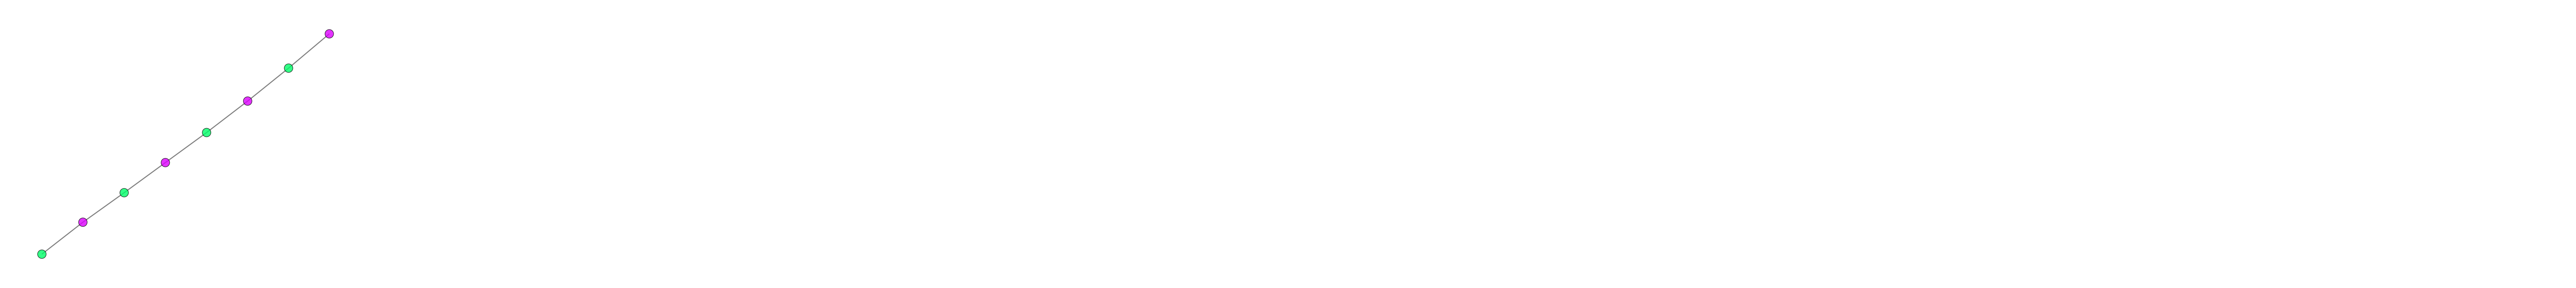

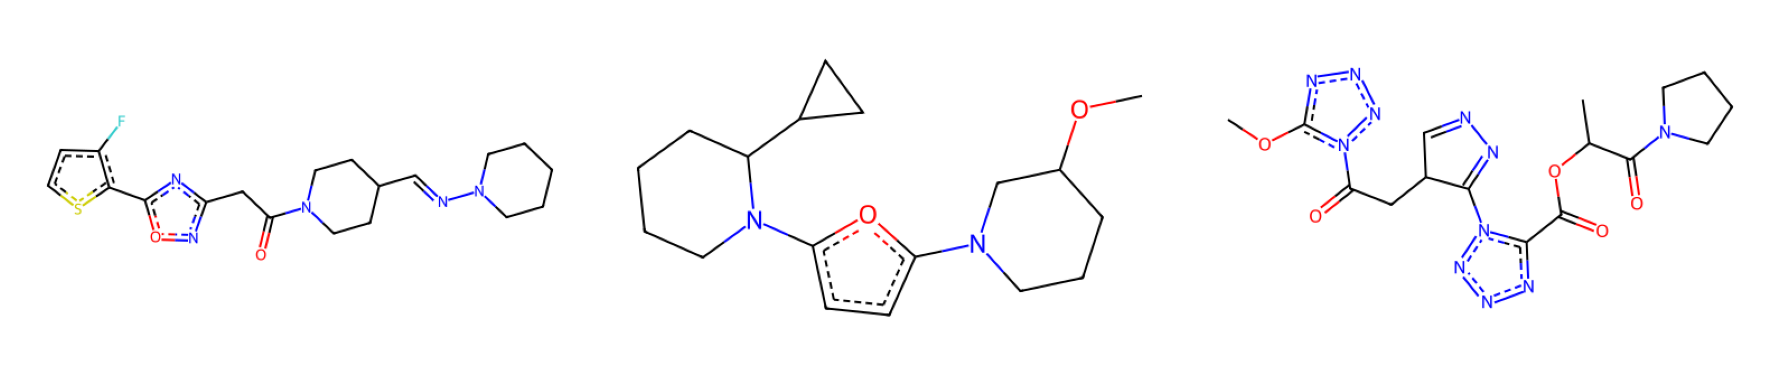

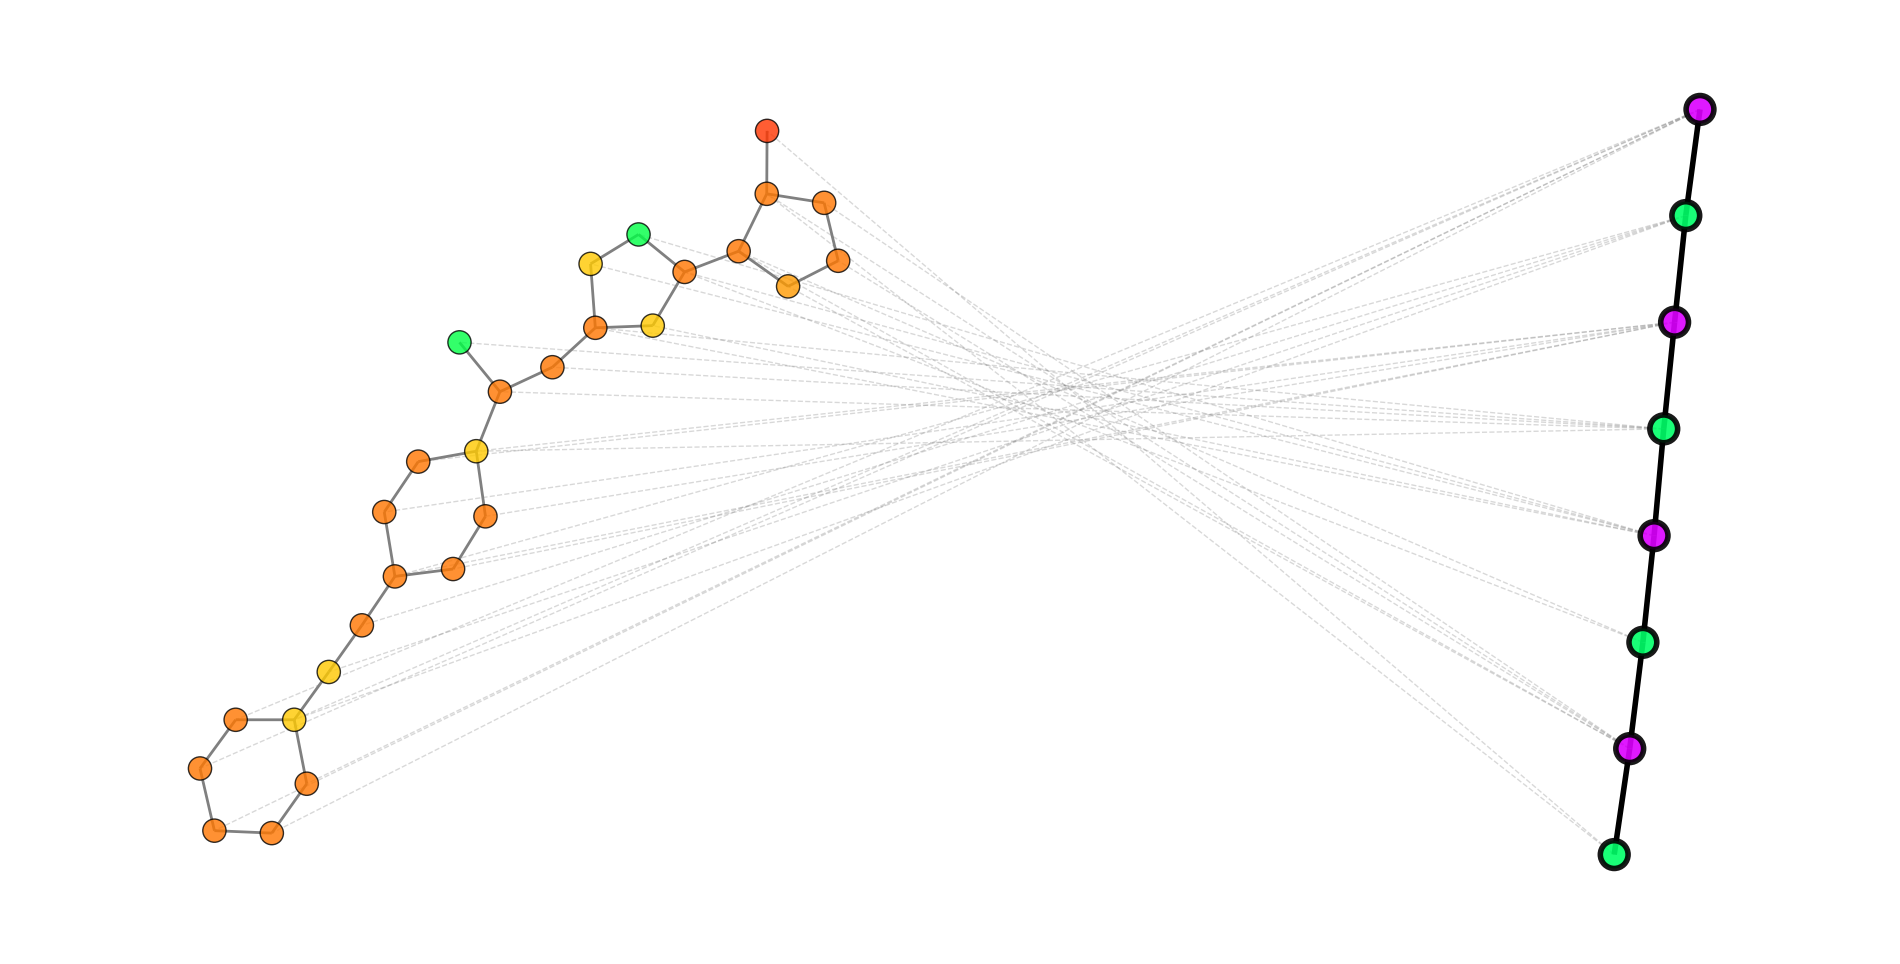

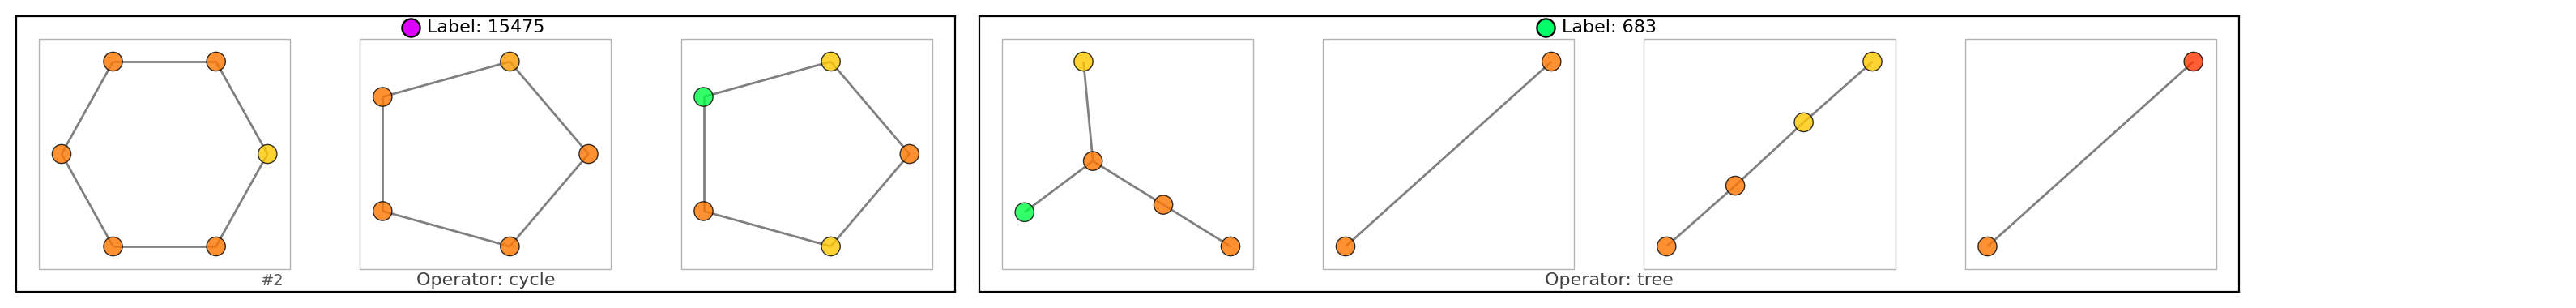

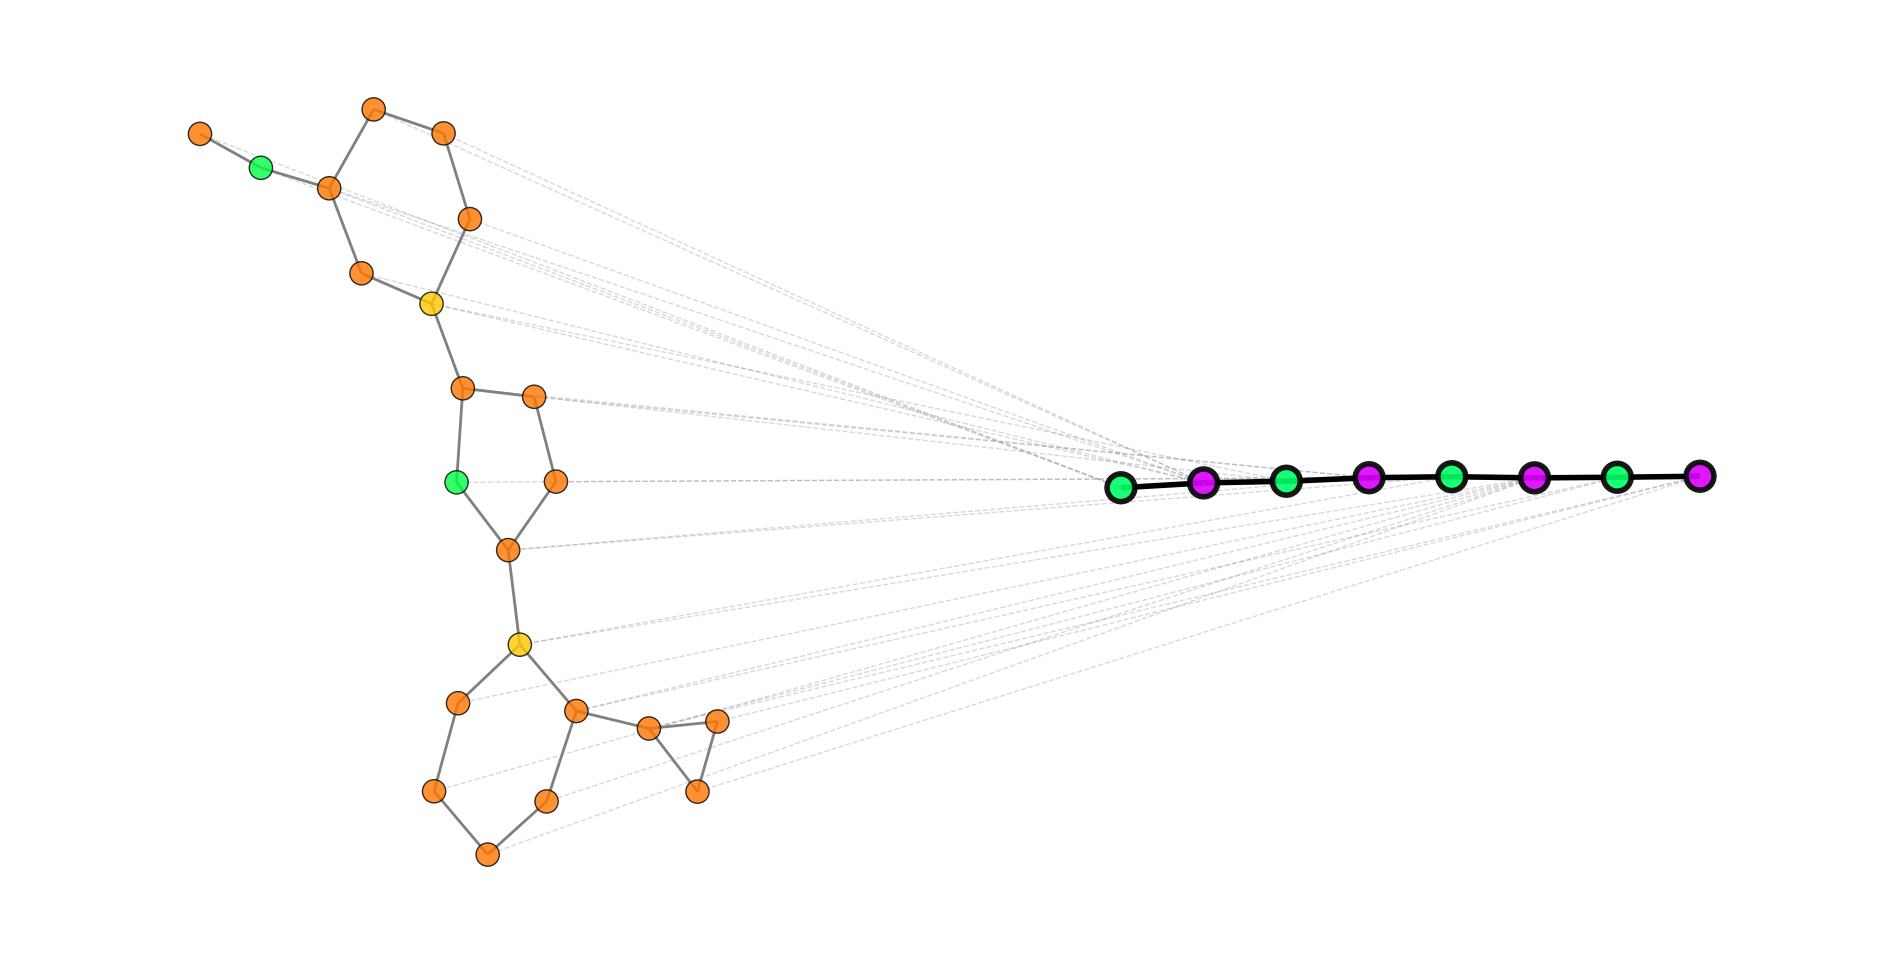

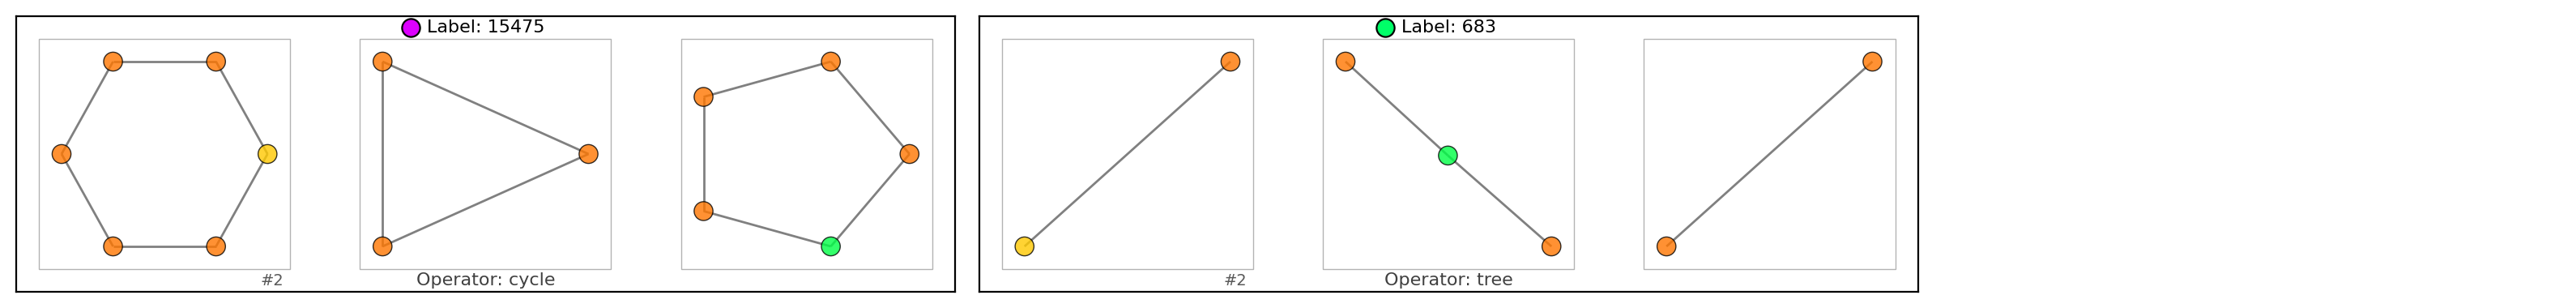

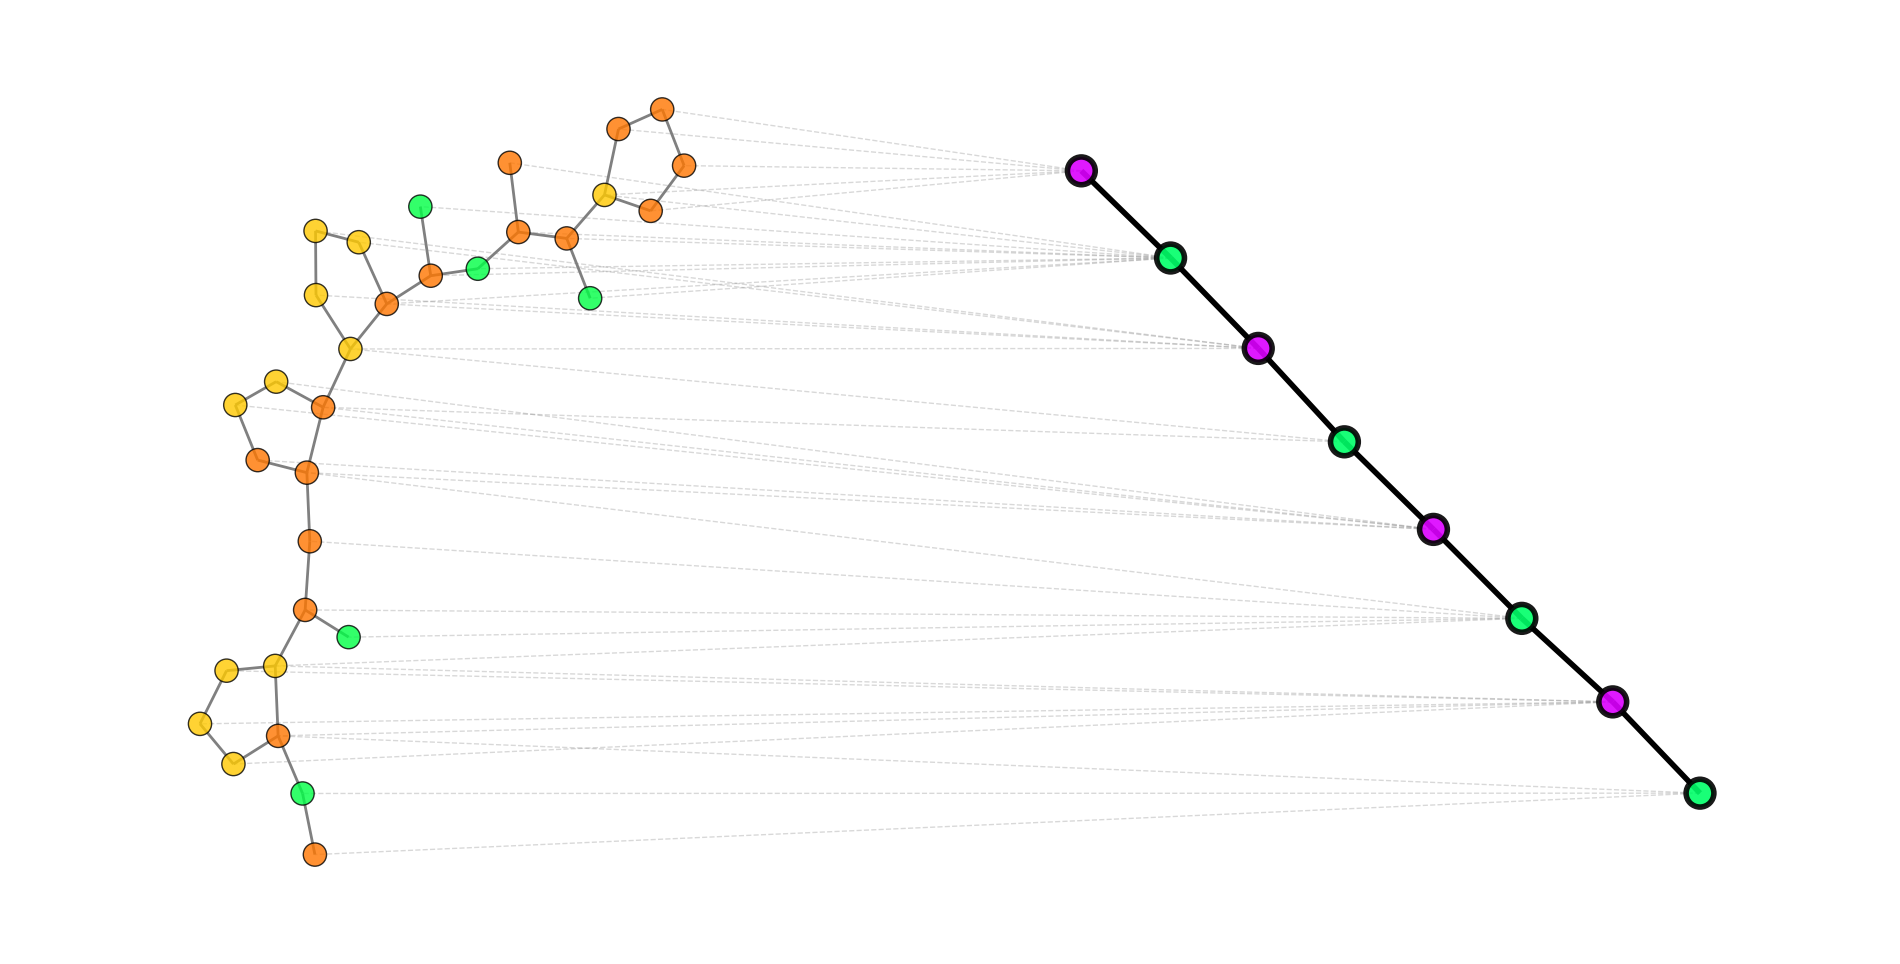

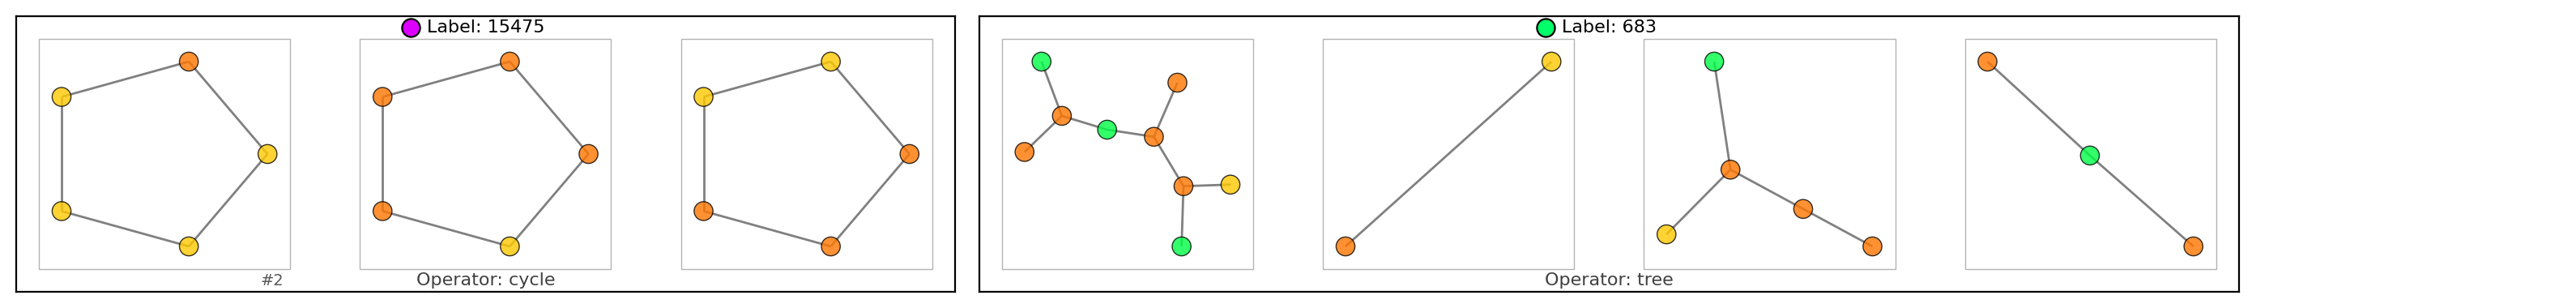

In [24]:
if not generated_graphs:
    print("No generated molecules to display.")
else:
    for sample_idx, (seed_idx,seed_graph,seed_interpretation_graph,generated_interpretation_graph,generated_instances,) in enumerate(zip(generator.last_successful_sampled_indices_,generator.last_seed_graphs_,generator.last_seed_interpretation_graphs_,generator.last_generated_interpretation_graphs_,generated_groups,)):
        print("=" * 120)
        print(f"sample {sample_idx} | seed index {seed_idx}")

        print("seed molecule")
        display_graphs([seed_graph], n_graphs_per_line=1)

        print("seed interpretation graph")
        display([seed_interpretation_graph], size=(5, 4))

        print("generated interpretation graph")
        display([generated_interpretation_graph], size=(5, 4))

        print(f"generated molecule instances ({len(generated_instances)})")
        display_graphs(generated_instances, n_graphs_per_line=n_instances_per_sample)
        for generated_instance in generated_instances:
            draw(generated_instance, decomposition_function=decomposition_function, nbits=nbits, label_mode=label_mode)
